# Détection du Paludisme par Deep Learning

## Contexte
Le paludisme est une maladie parasitaire potentiellement mortelle causée par une infection par un protozoaire Plasmodium transmis par un moustique anophèle femelle infectieux.

Ce projet vise à créer un modèle de deep learning capable de distinguer automatiquement les cellules infectées par le paludisme de celles qui ne le sont pas.

## Structure du Dataset
- **Parasitized**: ~13,780 images de cellules infectées
- **Uninfected**: ~13,780 images de cellules non infectées


In [1]:
# Importation des bibliothèques nécessaires
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime
from PIL import Image
import warnings
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf


warnings.filterwarnings('ignore')

# Configuration pour l'affichage
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


2025-11-03 13:42:16.354055: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
#  Vérification robustesse des chemins images et fallback automatique debug
N_DEBUG = 2000  # Taille debug fallback rapide

def check_and_fallback(df, min_valid=0.98, n_debug=N_DEBUG):
    """
    Vérifie si tous les chemins images du df existent.
    Si < min_valid (ex: <98% valides), renvoie un DataFrame d'échantillon debug.
    """
    exists = df['path'].map(os.path.exists)
    percent_valide = exists.mean()
    print(f"Chemins valides: {percent_valide*100:.1f}% ({exists.sum()} / {len(df)})")
    if percent_valide < min_valid:
        print(f"==> Seulement {percent_valide*100:.1f}% valides. Utilisation d'un sous-échantillon DEBUG de {n_debug} images...")
        df_ok = df[exists].sample(n=min(n_debug, exists.sum()), random_state=42).reset_index(drop=True)
        return df_ok
    elif percent_valide < 1.0:
        print(f"==> Certains chemins sont invalides ({len(df) - exists.sum()} images ignorées).")
        df_ok = df[exists].reset_index(drop=True)
        return df_ok
    else:
        print("Tous les chemins sont valides.")
        return df

# Utilisation : appelez à la place de df avant split/train_gen/val_gen/test_gen
# Ex:
# df_checked = check_and_fallback(df)
# puis utiliser df_checked partout pour splits/générateurs



## 1. Chargement de l'ensemble de données


In [3]:
# Définition des chemins des données
base_dir = 'cell_images'
parasitized_dir = os.path.join(base_dir, 'Parasitized')
uninfected_dir = os.path.join(base_dir, 'Uninfected')

# Vérification de l'existence des dossiers
print(f"Parasitized directory exists: {os.path.exists(parasitized_dir)}")
print(f"Uninfected directory exists: {os.path.exists(uninfected_dir)}")

# Comptage du nombre d'images dans chaque catégorie
parasitized_images = [f for f in os.listdir(parasitized_dir) if f.endswith('.png')]
uninfected_images = [f for f in os.listdir(uninfected_dir) if f.endswith('.png')]

print(f"\nNombre d'images parasitized: {len(parasitized_images)}")
print(f"Nombre d'images uninfected: {len(uninfected_images)}")
print(f"Nombre total d'images: {len(parasitized_images) + len(uninfected_images)}")


Parasitized directory exists: True
Uninfected directory exists: True

Nombre d'images parasitized: 13779
Nombre d'images uninfected: 13779
Nombre total d'images: 27558


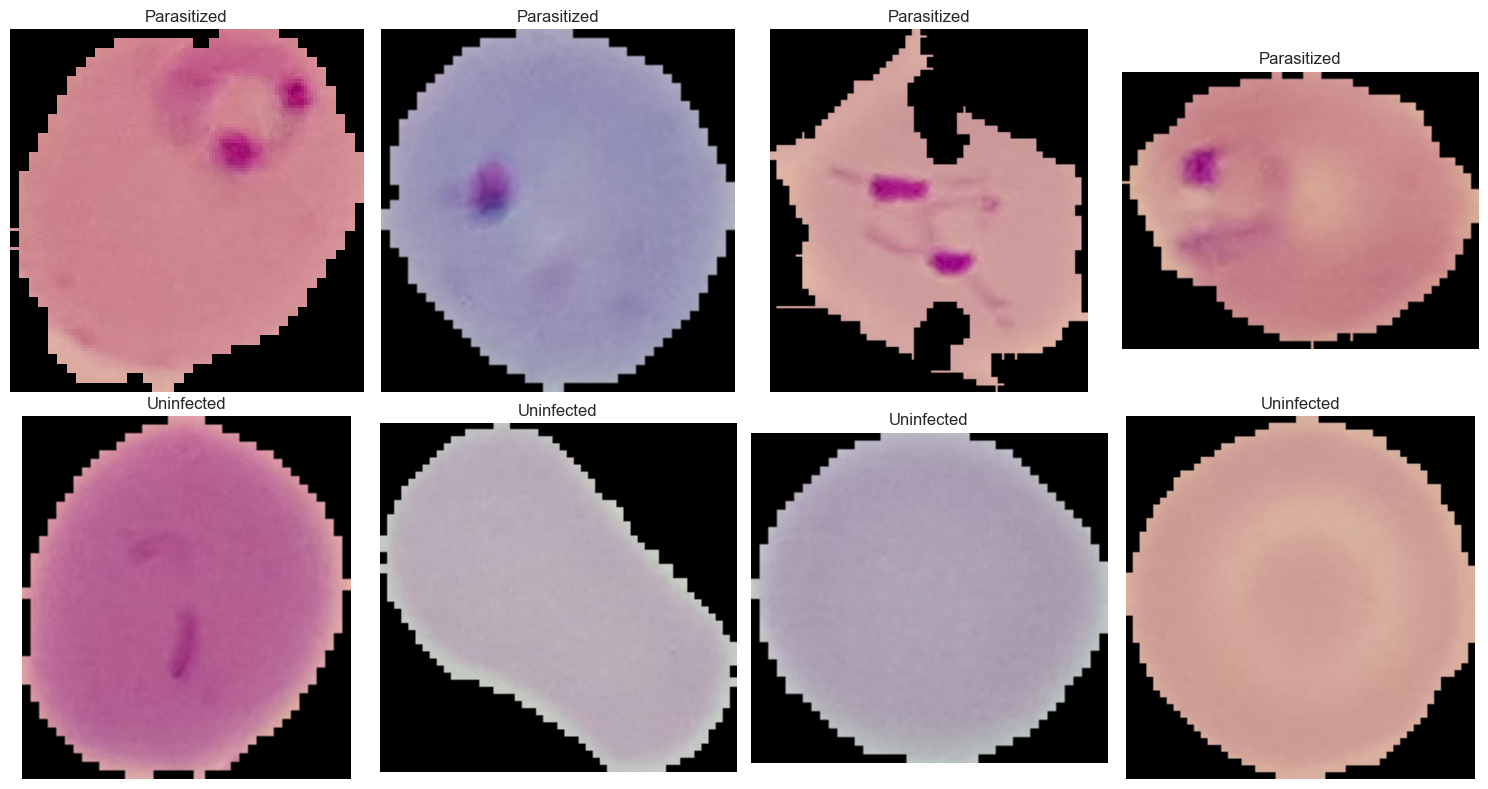

In [4]:
# Visualisation de quelques exemples d'images
fig, axes = plt.subplots(2, 4, figsize=(15, 8))

# Afficher des images parasitized
for i in range(4):
    img_path = os.path.join(parasitized_dir, parasitized_images[i])
    img = Image.open(img_path)
    axes[0, i].imshow(img)
    axes[0, i].set_title('Parasitized')
    axes[0, i].axis('off')

# Afficher des images uninfected
for i in range(4):
    img_path = os.path.join(uninfected_dir, uninfected_images[i])
    img = Image.open(img_path)
    axes[1, i].imshow(img)
    axes[1, i].set_title('Uninfected')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()


In [5]:
# Création d'un DataFrame pour organiser les données
data = []

# Ajout des images parasitized
for img in parasitized_images:
    data.append({
        'filename': img,
        'label': 'Parasitized',
        'path': os.path.join(parasitized_dir, img)
    })

# Ajout des images uninfected
for img in uninfected_images:
    data.append({
        'filename': img,
        'label': 'Uninfected',
        'path': os.path.join(uninfected_dir, img)
    })

df = pd.DataFrame(data)
print(f"\nDataFrame créé avec {len(df)} lignes")
print(f"\nDistribution des classes:")
print(df['label'].value_counts())

# Afficher les premières lignes
df.head(10)



DataFrame créé avec 27558 lignes

Distribution des classes:
label
Parasitized    13779
Uninfected     13779
Name: count, dtype: int64


,filename,label,path
0,C118P79ThinF_IMG_20151002_105018_cell_150.png,Parasitized,cell_images/Parasitized/C118P79ThinF_IMG_20151...
1,C189P150ThinF_IMG_20151203_142224_cell_84.png,Parasitized,cell_images/Parasitized/C189P150ThinF_IMG_2015...
2,C91P52ThinF_IMG_20150821_123116_cell_189.png,Parasitized,cell_images/Parasitized/C91P52ThinF_IMG_201508...
3,C84P45ThinF_IMG_20150818_101226_cell_98.png,Parasitized,cell_images/Parasitized/C84P45ThinF_IMG_201508...
4,C144P105ThinF_IMG_20151015_163432_cell_310.png,Parasitized,cell_images/Parasitized/C144P105ThinF_IMG_2015...
5,C136P97ThinF_IMG_20151005_141803_cell_131.png,Parasitized,cell_images/Parasitized/C136P97ThinF_IMG_20151...
6,C65P26N_ThinF_IMG_20150818_154050_cell_177.png,Parasitized,cell_images/Parasitized/C65P26N_ThinF_IMG_2015...
7,C60P21thinF_IMG_20150804_105034_cell_105.png,Parasitized,cell_images/Parasitized/C60P21thinF_IMG_201508...
8,C109P70ThinF_IMG_20150930_103811_cell_159.png,Parasitized,cell_images/Parasitized/C109P70ThinF_IMG_20150...
9,C176P137NThinF_IMG_20151201_122708_cell_126.png,Parasitized,cell_images/Parasitized/C176P137NThinF_IMG_201...


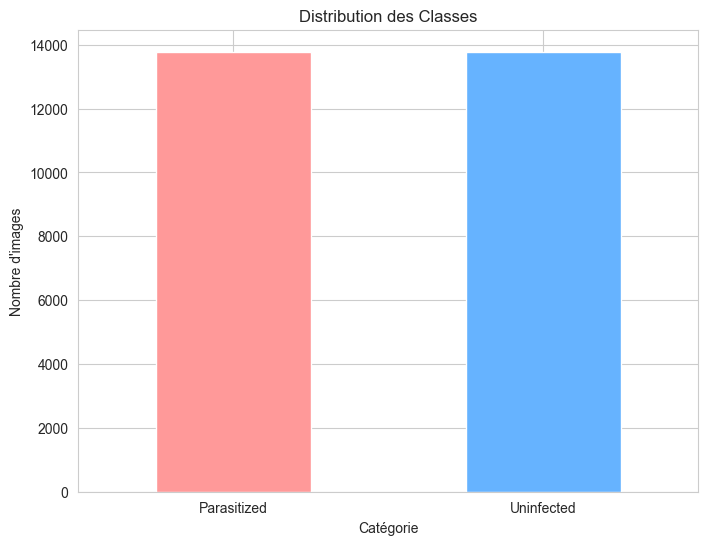

Pourcentage de cellules parasitized: 50.00%
Pourcentage de cellules uninfected: 50.00%


In [6]:
# Visualisation de la distribution des classes
plt.figure(figsize=(8, 6))
df['label'].value_counts().plot(kind='bar', color=['#ff9999', '#66b3ff'])
plt.title('Distribution des Classes')
plt.xlabel('Catégorie')
plt.ylabel('Nombre d\'images')
plt.xticks(rotation=0)
plt.show()

# Afficher les statistiques
print(f"Pourcentage de cellules parasitized: {df[df['label']=='Parasitized'].shape[0]/len(df)*100:.2f}%")
print(f"Pourcentage de cellules uninfected: {df[df['label']=='Uninfected'].shape[0]/len(df)*100:.2f}%")


In [7]:
# Examiner la taille de quelques images
def get_image_size(image_path):
    with Image.open(image_path) as img:
        return img.size

sample_parasitized = df[df['label']=='Parasitized'].iloc[0]['path']
sample_uninfected = df[df['label']=='Uninfected'].iloc[0]['path']

print(f"Taille d'une image parasitized (échantillon): {get_image_size(sample_parasitized)}")
print(f"Taille d'une image uninfected (échantillon): {get_image_size(sample_uninfected)}")

# Charger et afficher les informations de quelques images
img_para = Image.open(sample_parasitized)
img_uninf = Image.open(sample_uninfected)

print(f"\nMode de l'image parasitized: {img_para.mode}")
print(f"Mode de l'image uninfected: {img_uninf.mode}")

# Convertir en array numpy pour voir la forme
img_para_array = np.array(img_para)
img_uninf_array = np.array(img_uninf)

print(f"\nForme de l'array parasitized: {img_para_array.shape}")
print(f"Forme de l'array uninfected: {img_uninf_array.shape}")


Taille d'une image parasitized (échantillon): (112, 115)
Taille d'une image uninfected (échantillon): (115, 127)

Mode de l'image parasitized: RGB
Mode de l'image uninfected: RGB

Forme de l'array parasitized: (115, 112, 3)
Forme de l'array uninfected: (127, 115, 3)


## 2. Prétraitement des données

Dans cette section, nous allons:
- Lire les images et leurs étiquettes
- Redimensionner les images à une taille standard
- Normaliser les valeurs des pixels
- Préparer les données pour le modèle


In [8]:
# Fonction pour charger et prétraiter une image
def load_and_preprocess_image(image_path, target_size=(100, 100)):
    """
    Charge une image, la redimensionne et la normalise.
    
    Parameters:
    - image_path: chemin de l'image
    - target_size: taille cible (height, width)
    
    Returns:
    - image_array: tableau numpy de l'image normalisée
    """
    img = Image.open(image_path)
    img = img.resize(target_size)
    img_array = np.array(img)
    
    # Normaliser les valeurs entre 0 et 1
    img_array = img_array.astype('float32') / 255.0
    
    return img_array

# Afficher un exemple de chargement
example_img = load_and_preprocess_image(df.iloc[0]['path'])
print(f"Forme de l'image après prétraitement: {example_img.shape}")
print(f"Valeurs min/max: {example_img.min()}/{example_img.max()}")
print(f"Type de données: {example_img.dtype}")


Forme de l'image après prétraitement: (100, 100, 3)
Valeurs min/max: 0.0/0.9647058844566345
Type de données: float32


In [9]:

N = 2000  
df_sample = df.sample(N, random_state=42).reset_index(drop=True)

from concurrent.futures import ThreadPoolExecutor

# Définit la taille d'entrée utilisée par preprocess_row
IMG_SIZE = (100, 100)

def preprocess_row(row):
    img_array = load_and_preprocess_image(row['path'], target_size=IMG_SIZE)
    label = 1 if row['label'] == 'Parasitized' else 0
    return img_array, label

rows = [row for _, row in df_sample.iterrows()]
X, y = [], []
print("Chargement et prétraitement (parallélisé) en cours...")
with ThreadPoolExecutor() as executor:
    results = list(executor.map(preprocess_row, rows))

for img_array, label in results:
    X.append(img_array)
    y.append(label)
    
print(f"\nChargement terminé! {len(X)} images prêtes (utilise N=len(df) pour charger tout)")


Chargement et prétraitement (parallélisé) en cours...

Chargement terminé! 2000 images prêtes (utilise N=len(df) pour charger tout)


In [10]:
# Convertir en arrays numpy
X = np.array(X)
y = np.array(y)

print(f"Forme de X: {X.shape}")
print(f"Forme de y: {y.shape}")
print(f"\nExemple de valeurs de X:")
print(f"  Min: {X.min()}, Max: {X.max()}, Mean: {X.mean():.4f}")
print(f"\nDistribution des labels:")
print(f"  Parasitized (1): {(y == 1).sum()}")
print(f"  Uninfected (0): {(y == 0).sum()}")


Forme de X: (2000, 100, 100, 3)
Forme de y: (2000,)

Exemple de valeurs de X:
  Min: 0.0, Max: 1.0, Mean: 0.4698

Distribution des labels:
  Parasitized (1): 1030
  Uninfected (0): 970


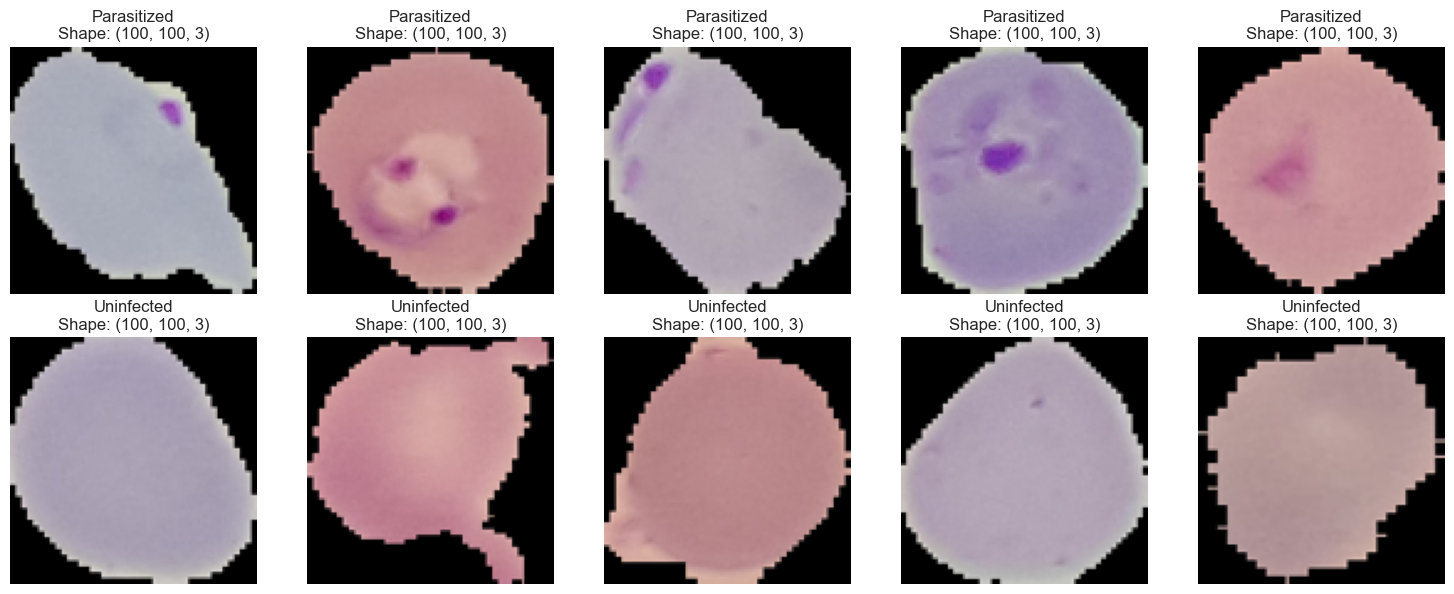

In [11]:
# Visualiser quelques images après prétraitement
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Afficher des images parasitized
parasitized_indices = np.where(y == 1)[0][:5]
for i, idx in enumerate(parasitized_indices):
    axes[0, i].imshow(X[idx])
    axes[0, i].set_title(f'Parasitized\nShape: {X[idx].shape}')
    axes[0, i].axis('off')

# Afficher des images uninfected
uninfected_indices = np.where(y == 0)[0][:5]
for i, idx in enumerate(uninfected_indices):
    axes[1, i].imshow(X[idx])
    axes[1, i].set_title(f'Uninfected\nShape: {X[idx].shape}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()


In [12]:
# Vérifier la cohérence des données
print("=== Vérification des données ===")
print(f"Nombre d'images chargées: {len(X)}")
print(f"Nombre de labels: {len(y)}")
print(f"Forme des images: {X.shape}")
print(f"Type de données de X: {X.dtype}")
print(f"Type de données de y: {y.dtype}")
print(f"\nÉchantillons de valeurs X:")
print(f"  Premier pixel de la première image: {X[0, 0, 0]}")
print(f"  Valeurs min/max: {X.min():.4f}/{X.max():.4f}")
print(f"\nDistribution des labels y:")
unique, counts = np.unique(y, return_counts=True)
for val, count in zip(unique, counts):
    label_name = 'Parasitized' if val == 1 else 'Uninfected'
    print(f"  {label_name} ({val}): {count}")


=== Vérification des données ===
Nombre d'images chargées: 2000
Nombre de labels: 2000
Forme des images: (2000, 100, 100, 3)
Type de données de X: float32
Type de données de y: int64

Échantillons de valeurs X:
  Premier pixel de la première image: [0. 0. 0.]
  Valeurs min/max: 0.0000/1.0000

Distribution des labels y:
  Uninfected (0): 970
  Parasitized (1): 1030


## 3. Affichage des Images avec leurs Étiquettes

Dans cette section, nous visualisons des exemples d'images de cellules parasitized et uninfected avec leurs étiquettes respectives.


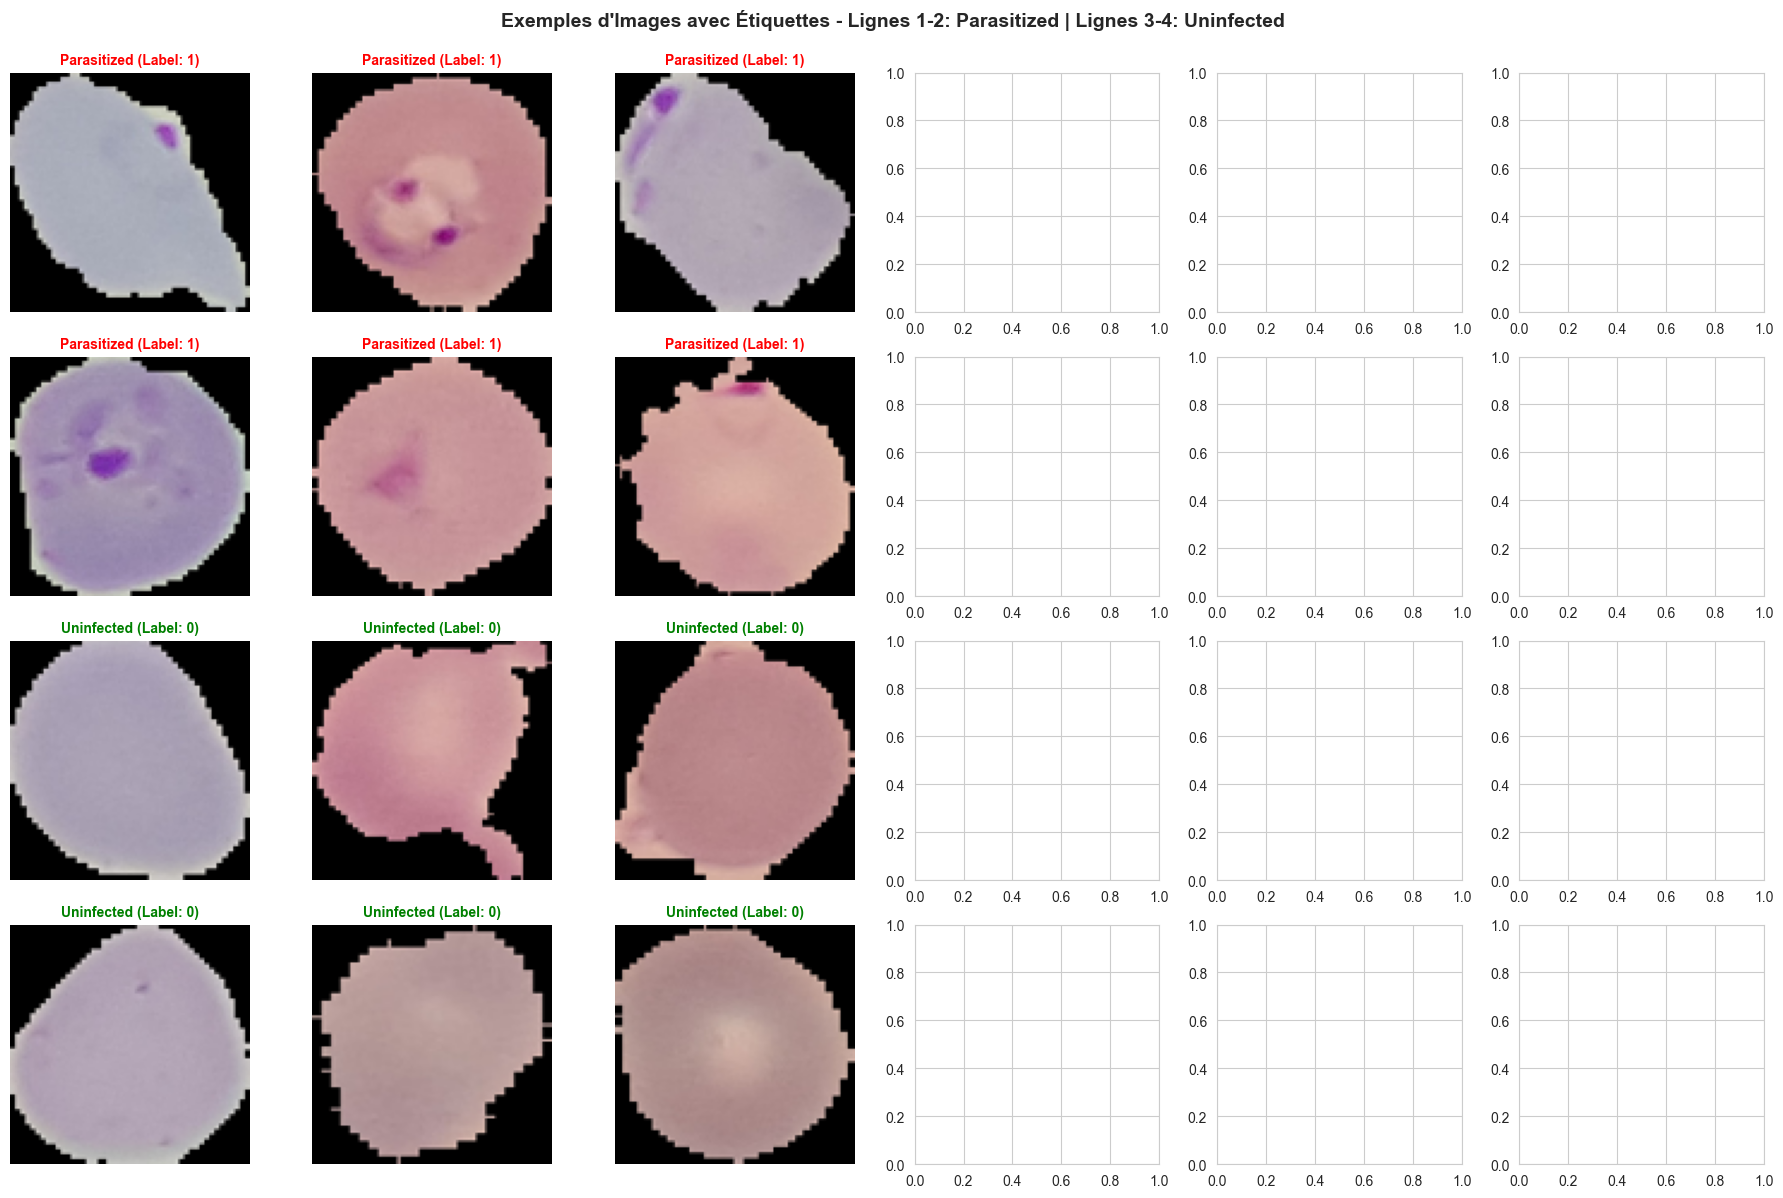

In [13]:
# Afficher des exemples d'images avec leurs étiquettes
fig, axes = plt.subplots(4, 6, figsize=(18, 12))

# Indices pour les images parasitized et uninfected
parasitized_indices = np.where(y == 1)[0][:6]
uninfected_indices = np.where(y == 0)[0][:6]

# Afficher 6 images parasitized sur les 2 premières lignes
for i, idx in enumerate(parasitized_indices):
    row = i // 3
    col = i % 3
    axes[row, col].imshow(X[idx])
    axes[row, col].set_title(f'Parasitized (Label: {y[idx]})', color='red', fontsize=10, fontweight='bold')
    axes[row, col].axis('off')

# Afficher 6 images uninfected sur les 2 dernières lignes
for i, idx in enumerate(uninfected_indices):
    row = 2 + (i // 3)
    col = i % 3
    axes[row, col].imshow(X[idx])
    axes[row, col].set_title(f'Uninfected (Label: {y[idx]})', color='green', fontsize=10, fontweight='bold')
    axes[row, col].axis('off')

plt.suptitle('Exemples d\'Images avec Étiquettes - Lignes 1-2: Parasitized | Lignes 3-4: Uninfected', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


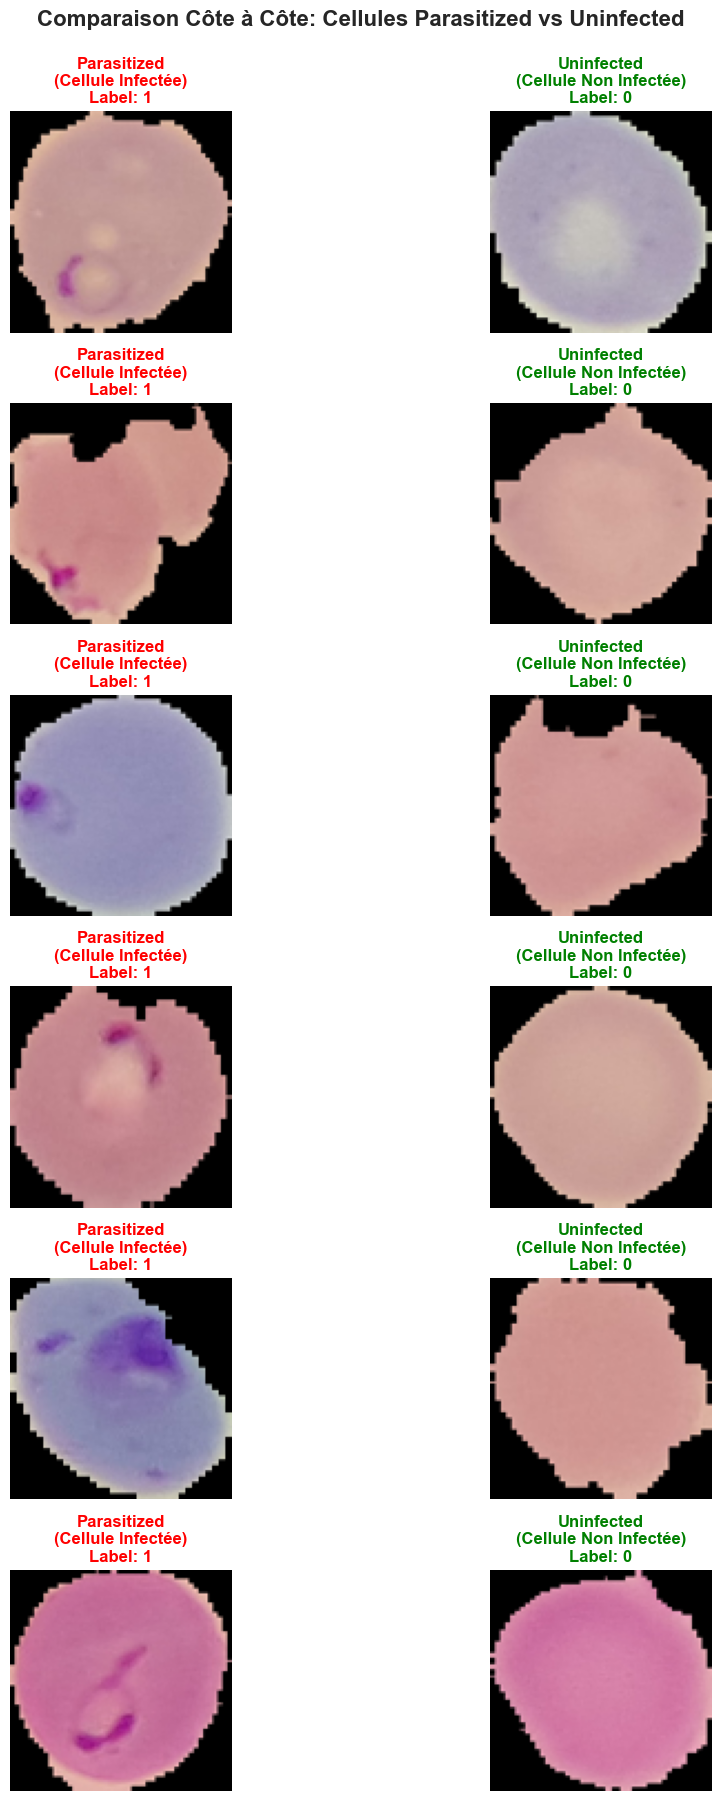

In [14]:
# Comparaison côte à côte: Parasitized vs Uninfected
fig, axes = plt.subplots(6, 2, figsize=(12, 18))

# Prendre 6 échantillons de chaque type
np.random.seed(42)
parasitized_sample = np.random.choice(np.where(y == 1)[0], 6, replace=False)
uninfected_sample = np.random.choice(np.where(y == 0)[0], 6, replace=False)

# Afficher 6 paires comparatives
for i in range(6):
    # Image parasitized
    axes[i, 0].imshow(X[parasitized_sample[i]])
    axes[i, 0].set_title('Parasitized\n(Cellule Infectée)\nLabel: 1', 
                        color='red', fontsize=12, fontweight='bold')
    axes[i, 0].axis('off')
    
    # Image uninfected correspondante
    axes[i, 1].imshow(X[uninfected_sample[i]])
    axes[i, 1].set_title('Uninfected\n(Cellule Non Infectée)\nLabel: 0', 
                        color='green', fontsize=12, fontweight='bold')
    axes[i, 1].axis('off')

plt.suptitle('Comparaison Côte à Côte: Cellules Parasitized vs Uninfected', 
             fontsize=16, fontweight='bold', y=0.998)
plt.tight_layout()
plt.show()


🔴 Exemple d'image PARASITIZED (Label: 1)


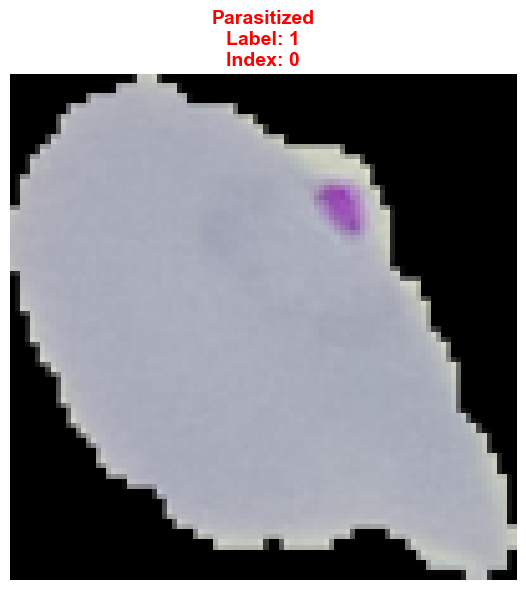


 Informations de l'image:
   Label: Parasitized (code numérique: 1)
   Forme: (100, 100, 3)
   Intensité min: 0.0000
   Intensité max: 0.8784
   Intensité moyenne: 0.4471

🟢 Exemple d'image UNINFECTED (Label: 0)


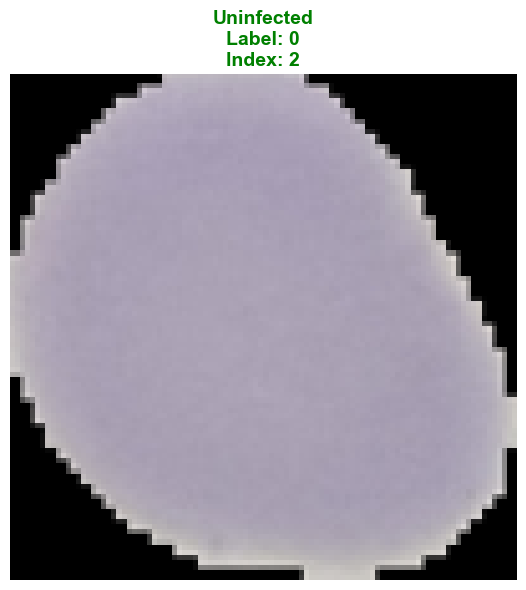


 Informations de l'image:
   Label: Uninfected (code numérique: 0)
   Forme: (100, 100, 3)
   Intensité min: 0.0000
   Intensité max: 0.8863
   Intensité moyenne: 0.5152


In [15]:
# Afficher des images aléatoires avec leurs informations complètes
def display_image_info(idx):
    """Affiche une image avec ses informations complètes"""
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    
    image = X[idx]
    label = y[idx]
    label_name = 'Parasitized' if label == 1 else 'Uninfected'
    label_color = 'red' if label == 1 else 'green'
    
    ax.imshow(image)
    ax.set_title(f'{label_name}\nLabel: {label}\nIndex: {idx}', 
                color=label_color, fontsize=14, fontweight='bold')
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n Informations de l'image:")
    print(f"   Label: {label_name} (code numérique: {label})")
    print(f"   Forme: {image.shape}")
    print(f"   Intensité min: {image.min():.4f}")
    print(f"   Intensité max: {image.max():.4f}")
    print(f"   Intensité moyenne: {image.mean():.4f}")

# Afficher un exemple de chaque classe
print("=" * 60)
print("🔴 Exemple d'image PARASITIZED (Label: 1)")
print("=" * 60)
parasitized_example = np.where(y == 1)[0][0]
display_image_info(parasitized_example)

print("\n" + "=" * 60)
print("🟢 Exemple d'image UNINFECTED (Label: 0)")
print("=" * 60)
uninfected_example = np.where(y == 0)[0][0]
display_image_info(uninfected_example)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


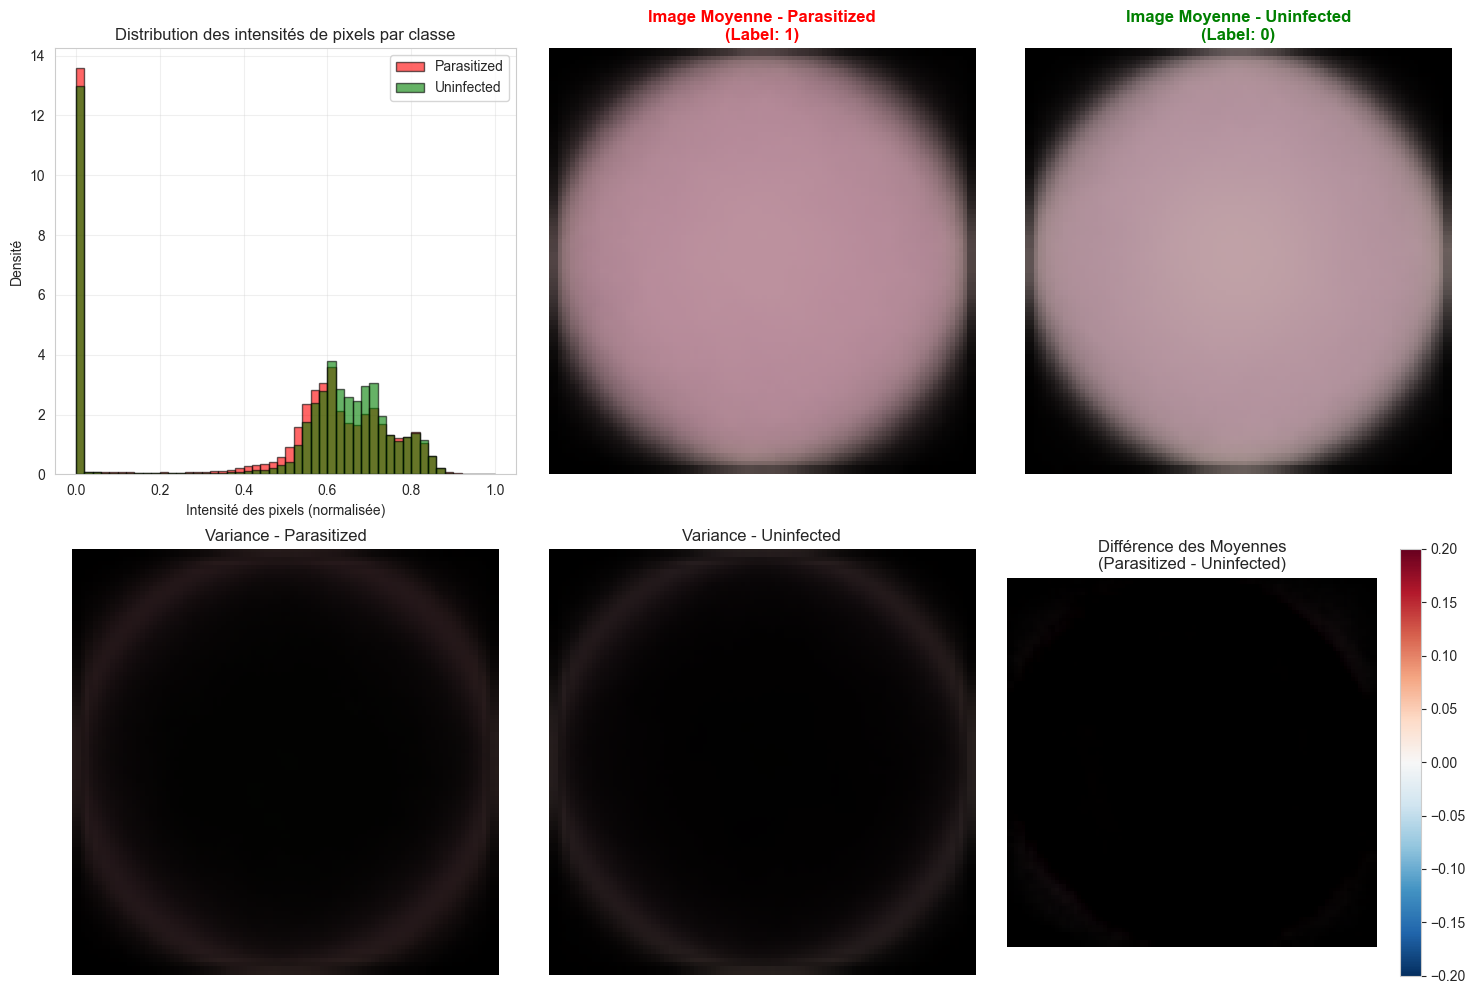

In [16]:
# Visualisation des statistiques des deux classes
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Séparer les images par classe
parasitized_images = X[y == 1]
uninfected_images = X[y == 0]

# 1. Histogramme des distributions des pixels
ax = axes[0, 0]
ax.hist(parasitized_images.flatten(), bins=50, alpha=0.6, color='red', 
        label='Parasitized', density=True, edgecolor='black')
ax.hist(uninfected_images.flatten(), bins=50, alpha=0.6, color='green', 
        label='Uninfected', density=True, edgecolor='black')
ax.set_xlabel('Intensité des pixels (normalisée)')
ax.set_ylabel('Densité')
ax.set_title('Distribution des intensités de pixels par classe')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# 2. Image moyenne pour chaque classe
mean_parasitized = parasitized_images.mean(axis=0)
mean_uninfected = uninfected_images.mean(axis=0)

axes[0, 1].imshow(mean_parasitized)
axes[0, 1].set_title('Image Moyenne - Parasitized\n(Label: 1)', color='red', fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(mean_uninfected)
axes[0, 2].set_title('Image Moyenne - Uninfected\n(Label: 0)', color='green', fontweight='bold')
axes[0, 2].axis('off')

# 3. Variance des pixels
axes[1, 0].imshow(parasitized_images.var(axis=0), cmap='hot')
axes[1, 0].set_title('Variance - Parasitized')
axes[1, 0].axis('off')

axes[1, 1].imshow(uninfected_images.var(axis=0), cmap='hot')
axes[1, 1].set_title('Variance - Uninfected')
axes[1, 1].axis('off')

# 4. Différence entre les moyennes
diff = mean_parasitized - mean_uninfected
im = axes[1, 2].imshow(diff, cmap='RdBu_r', vmin=-0.2, vmax=0.2)
axes[1, 2].set_title('Différence des Moyennes\n(Parasitized - Uninfected)')
axes[1, 2].axis('off')
plt.colorbar(im, ax=axes[1, 2])

plt.tight_layout()
plt.show()


In [17]:
# Résumé statistique des données
print("=" * 70)
print(" RÉSUMÉ STATISTIQUE DES DONNÉES")
print("=" * 70)

print(f"\n1.  Informations générales:")
print(f"   • Nombre total d'images: {len(X):,}")
print(f"   • Dimensions des images: {X.shape[1]}x{X.shape[2]} pixels")
print(f"   • Nombre de canaux: {X.shape[3]} (RGB)")

print(f"\n2.  Répartition des classes:")
print(f"   • Cellules Parasitized (Label: 1): {len(parasitized_images):,} ({len(parasitized_images)/len(X)*100:.2f}%)")
print(f"   • Cellules Uninfected (Label: 0): {len(uninfected_images):,} ({len(uninfected_images)/len(X)*100:.2f}%)")

print(f"\n3. 🔴 Statistiques des pixels (Parasitized - Label: 1):")
print(f"   • Min: {parasitized_images.min():.4f}")
print(f"   • Max: {parasitized_images.max():.4f}")
print(f"   • Moyenne: {parasitized_images.mean():.4f}")
print(f"   • Écart-type: {parasitized_images.std():.4f}")

print(f"\n4. 🟢 Statistiques des pixels (Uninfected - Label: 0):")
print(f"   • Min: {uninfected_images.min():.4f}")
print(f"   • Max: {uninfected_images.max():.4f}")
print(f"   • Moyenne: {uninfected_images.mean():.4f}")
print(f"   • Écart-type: {uninfected_images.std():.4f}")

print("\n" + "=" * 70)


 RÉSUMÉ STATISTIQUE DES DONNÉES

1.  Informations générales:
   • Nombre total d'images: 2,000
   • Dimensions des images: 100x100 pixels
   • Nombre de canaux: 3 (RGB)

2.  Répartition des classes:
   • Cellules Parasitized (Label: 1): 1,030 (51.50%)
   • Cellules Uninfected (Label: 0): 970 (48.50%)

3. 🔴 Statistiques des pixels (Parasitized - Label: 1):
   • Min: 0.0000
   • Max: 1.0000
   • Moyenne: 0.4587
   • Écart-type: 0.3021

4. 🟢 Statistiques des pixels (Uninfected - Label: 0):
   • Min: 0.0000
   • Max: 1.0000
   • Moyenne: 0.4816
   • Écart-type: 0.3029



## 4. Normalisation des données d'image

Les données d'image (X) ont été normalisées lors du prétraitement : chaque pixel est maintenant compris dans l'intervalle [0, 1].

Nous vérifions que la normalisation est correcte et affichons les statistiques globales.


Valeur min (doit être >= 0)   : 0.0
Valeur max (doit être <= 1)   : 1.0
Moyenne globale des pixels    : 0.46983284
Canal Rouge -- Min: 0.0000 | Max: 1.0000 | Moyenne: 0.5294
Canal Vert -- Min: 0.0000 | Max: 0.9647 | Moyenne: 0.4250
Canal Bleu -- Min: 0.0000 | Max: 0.9255 | Moyenne: 0.4551


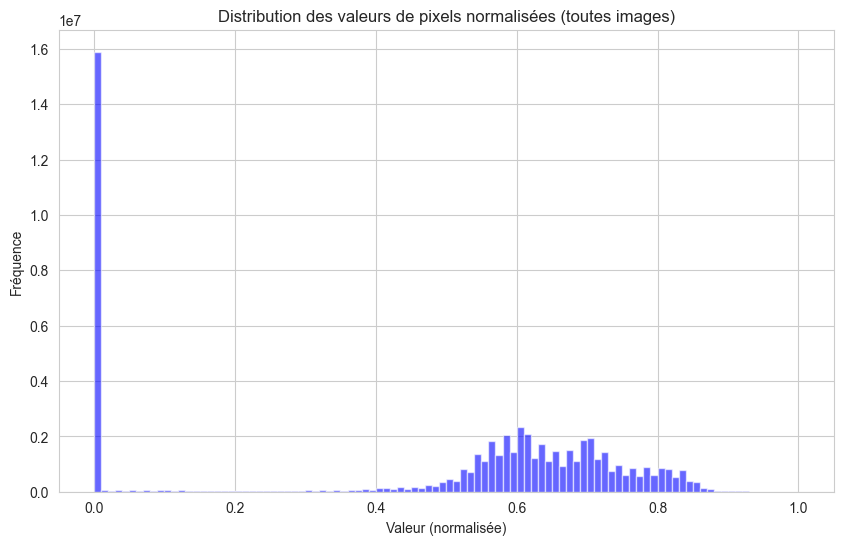

In [18]:
# Vérification finale de la normalisation
print('Valeur min (doit être >= 0)   :', X.min())
print('Valeur max (doit être <= 1)   :', X.max())
print('Moyenne globale des pixels    :', X.mean())

# Statistiques plus précises par canal
for c, nom in enumerate(['Rouge', 'Vert', 'Bleu']):
    print(f"Canal {nom} -- Min: {X[...,c].min():.4f} | Max: {X[...,c].max():.4f} | Moyenne: {X[...,c].mean():.4f}")

plt.hist(X.ravel(), bins=100, color='blue', alpha=0.6)
plt.title("Distribution des valeurs de pixels normalisées (toutes images)")
plt.xlabel("Valeur (normalisée)")
plt.ylabel("Fréquence")
plt.show()


## 5. Découpage du dataset et DataLoader - ImageDataGenerator

Nous allons maintenant découper les données en trois parties (entraînement, validation, test) puis utiliser `ImageDataGenerator` de Keras pour charger et augmenter les images à la volée de façon optimale lors de l'entraînement CNN.


In [19]:
# Division du DataFrame en splits entraînement / validation / test
# Utilise df_sample s'il existe, sinon tout df
df_used = df_sample if 'df_sample' in globals() else df

# 70% train, 15% val, 15% test avec stratification
# (via split en deux temps pour gardes proportions)
df_train, df_temp = train_test_split(df_used, test_size=0.3, stratify=df_used['label'], random_state=42)
df_val, df_test  = train_test_split(df_temp,   test_size=0.5, stratify=df_temp['label'], random_state=42)

print(f"Train: {len(df_train)} images")
print(f"Val  : {len(df_val)} images")
print(f"Test : {len(df_test)} images")


Train: 1400 images
Val  : 300 images
Test : 300 images


In [20]:
IMG_SIZE = (100, 100)
BATCH_SIZE = 32

# Data augmentation pour le train
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=8,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.02,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)
# Pas d’augmentation pour val/test
val_datagen = ImageDataGenerator(rescale=1./255)

def make_gen(datagen, dataframe, shuffle):
    return datagen.flow_from_dataframe(
        dataframe, x_col='path', y_col='label',
        target_size=IMG_SIZE, class_mode='binary',
        batch_size=BATCH_SIZE, shuffle=shuffle, seed=42
    )

train_gen = make_gen(train_datagen, df_train, shuffle=True)
val_gen   = make_gen(val_datagen,   df_val,   shuffle=False)
test_gen  = make_gen(val_datagen,   df_test,  shuffle=False)

# Afficher un batch pour vérif
X_batch, y_batch = next(train_gen)
print(f"Exemple batch X: {X_batch.shape}, y: {y_batch[:8]}")


Found 1400 validated image filenames belonging to 2 classes.
Found 300 validated image filenames belonging to 2 classes.
Found 300 validated image filenames belonging to 2 classes.
Exemple batch X: (32, 100, 100, 3), y: [0. 1. 1. 0. 0. 0. 0. 0.]


## 6. Création et entraînement de 3 modèles CNN sous Keras

Nous allons définir trois architectures CNN de complexité croissante afin de comparer leurs résultats sur la détection de cellules parasitées vs. non-infectées.


In [21]:
N_CLASSES = 1 # binaire

# EarlyStopping commun
early_stop = EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss')

# --------- MODELE 1 : Baseline simple CNN ---------
model_simple = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(100, 100, 3)),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(N_CLASSES, activation='sigmoid')
])
model_simple.compile(optimizer=Adam(learning_rate=1e-3), loss='binary_crossentropy', metrics=['accuracy'])
print(model_simple.summary())

# ===== Entraînement modèle simple =====
hist_simple = model_simple.fit(
    train_gen,
    epochs=10, validation_data=val_gen,
    steps_per_epoch=len(train_gen), validation_steps=len(val_gen),
    callbacks=[early_stop], verbose=2
)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 76832)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │     2,458,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,459,585 (9.38 MB)

 Trainable params: 2,459,585 (9.38 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/10
44/44 - 10s - 231ms/step - accuracy: 0.5686 - loss: 0.8392 - val_accuracy: 0.6333 - val_loss: 0.6656
Epoch 2/10
44/44 - 8s - 181ms/step - accuracy: 0.6214 - loss: 0.6532 - val_accuracy: 0.5800 - val_loss: 0.6957
Epoch 3/10
44/44 - 8s - 171ms/step - accuracy: 0.6393 - loss: 0.6402 - val_accuracy: 0.6133 - val_loss: 0.6745
Epoch 4/10
44/44 - 7s - 156ms/step - accuracy: 0.6600 - loss: 0.6279 - val_accuracy: 0.5967 - val_loss: 0.6574
Epoch 5/10
44/44 - 8s - 179ms/step - accuracy: 0.6529 - loss: 0.6269 - val_accuracy: 0.5967 - val_loss: 0.7189
Epoch 6/10
44/44 - 8s - 185ms/step - accuracy: 0.6171 - loss: 0.6473 - val_accuracy: 0.5533 - val_loss: 0.6685
Epoch 7/10
44/44 - 7s - 166ms/step - accuracy: 0.6421 - loss: 0.6399 - val_accuracy: 0.6033 - val_loss: 0.6785


In [22]:
# --------- MODELE 2 : CNN PROFOND (plus de couches, dropout, batchnorm) ---------
model_deep = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(100, 100, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),
    
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),
    
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.3),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(N_CLASSES, activation='sigmoid')
])
model_deep.compile(optimizer=Adam(learning_rate=1e-3), loss='binary_crossentropy', metrics=['accuracy'])
print(model_deep.summary())

# ===== Entraînement modèle profond =====
hist_deep = model_deep.fit(
    train_gen,
    epochs=15, validation_data=val_gen,
    steps_per_epoch=len(train_gen), validation_steps=len(val_gen),
    callbacks=[early_stop], verbose=2
)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 98, 98, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 47, 47, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 21, 21, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,732,801 (6.61 MB)

 Trainable params: 1,732,353 (6.61 MB)

 Non-trainable params: 448 (1.75 KB)

None
Epoch 1/15
44/44 - 21s - 468ms/step - accuracy: 0.5836 - loss: 1.1419 - val_accuracy: 0.4867 - val_loss: 3.9169
Epoch 2/15
44/44 - 16s - 373ms/step - accuracy: 0.6136 - loss: 0.6758 - val_accuracy: 0.4867 - val_loss: 4.2641
Epoch 3/15
44/44 - 17s - 387ms/step - accuracy: 0.6364 - loss: 0.6527 - val_accuracy: 0.4867 - val_loss: 2.8708


In [23]:
# --------- MODELE 3 : Inspiré VGG (mini-VGG) ---------
model_vgg = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(100, 100, 3)),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.25),
    
    Conv2D(64, (3,3), activation='relu', padding='same'),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.3),
    
    Conv2D(128, (3,3), activation='relu', padding='same'),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.35),
    
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(N_CLASSES, activation='sigmoid')
])
model_vgg.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])
print(model_vgg.summary())

# ===== Entraînement modèle VGG =====
hist_vgg = model_vgg.fit(
    train_gen,
    epochs=20, validation_data=val_gen,
    steps_per_epoch=len(train_gen), validation_steps=len(val_gen),
    callbacks=[early_stop], verbose=2
)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 100, 100, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 50, 50, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 25, 25, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,006,113 (19.10 MB)

 Trainable params: 5,006,113 (19.10 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/20
44/44 - 30s - 678ms/step - accuracy: 0.5079 - loss: 0.6982 - val_accuracy: 0.5733 - val_loss: 0.6929
Epoch 2/20
44/44 - 28s - 639ms/step - accuracy: 0.4957 - loss: 0.6922 - val_accuracy: 0.5633 - val_loss: 0.6920
Epoch 3/20
44/44 - 28s - 646ms/step - accuracy: 0.5550 - loss: 0.6873 - val_accuracy: 0.5900 - val_loss: 0.6831


## 7. Entraîner les modèles sur l'ensemble d'entraînement (cell_images)

Nous passons à l'entraînement sur tout le dataset (split train/val/test recomputé à partir de `df`).


In [24]:
# Recréer les splits et générateurs sur TOUT df (pas l'échantillon)
# Étape 0 : vérification automatisée des chemins (failover auto si pb !) 
df = check_and_fallback(df)

# 1) Splits
_df = df.copy().reset_index(drop=True)
df_train, df_temp = train_test_split(_df, test_size=0.3, stratify=_df['label'], random_state=42)
df_val, df_test  = train_test_split(df_temp, test_size=0.5, stratify=df_temp['label'], random_state=42)
print(f"Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

# 2) Générateurs (augmentation pour train) — mode rapide optionnel
IMG_SIZE = (100, 100)
BATCH_SIZE = 64  # batch plus grand pour réduire le nb de steps
FAST_MODE = True  # passe à False pour l'entraînement complet

if FAST_MODE:
    # Pas d'augmentation pour accélérer
    train_datagen = ImageDataGenerator(rescale=1./255)
else:
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=8,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.02,
        zoom_range=0.1,
        horizontal_flip=True,
        fill_mode='nearest'
    )
val_datagen = ImageDataGenerator(rescale=1./255)

def make_gen(datagen, dataframe, shuffle):
    return datagen.flow_from_dataframe(
        dataframe, x_col='path', y_col='label',
        target_size=IMG_SIZE, class_mode='binary',
        batch_size=BATCH_SIZE, shuffle=shuffle, seed=42
    )

train_gen = make_gen(train_datagen, df_train, shuffle=True)
val_gen   = make_gen(val_datagen,   df_val,   shuffle=False)
test_gen  = make_gen(val_datagen,   df_test,  shuffle=False)



Chemins valides: 100.0% (27558 / 27558)
Tous les chemins sont valides.
Train: 19290 | Val: 4134 | Test: 4134
Found 19290 validated image filenames belonging to 2 classes.
Found 4134 validated image filenames belonging to 2 classes.
Found 4134 validated image filenames belonging to 2 classes.


## 8. Pipeline optimal avec tf.data (parallel, cache, prefetch)

Créons des jeux `tf.data.Dataset` depuis `df_train/df_val/df_test` avec lecture parallèle, cache, batch et prefetch pour accélérer l'entraînement.


In [25]:
AUTO = tf.data.AUTOTUNE
BATCH_SIZE = 64
IMG_SIZE = (100, 100)

# Encodage binaire: 'Parasitized' -> 1, 'Uninfected' -> 0
label_to_int = {'Parasitized': 1, 'Uninfected': 0}

# Filtrer les chemins invalides AVANT construction des datasets (évite timeouts)
def filter_valid_paths(paths, labels):
    valid_mask = np.array([os.path.exists(str(p)) for p in paths])
    valid_paths = paths[valid_mask]
    valid_labels = labels[valid_mask]
    print(f"Chemins filtrés: {len(valid_paths)}/{len(paths)} valides")
    return valid_paths, valid_labels

# Préparer les chemins et labels
train_paths_raw = df_train['path'].values
train_labels_raw = df_train['label'].map(label_to_int).astype('int32').values
val_paths_raw = df_val['path'].values
val_labels_raw = df_val['label'].map(label_to_int).astype('int32').values
test_paths_raw = df_test['path'].values
test_labels_raw = df_test['label'].map(label_to_int).astype('int32').values

# Filtrer les invalides
print("Filtrage des chemins invalides...")
train_paths, train_labels = filter_valid_paths(train_paths_raw, train_labels_raw)
val_paths, val_labels = filter_valid_paths(val_paths_raw, val_labels_raw)
test_paths, test_labels = filter_valid_paths(test_paths_raw, test_labels_raw)

# Fonction de chargement avec gestion d'erreur robuste
def load_and_preprocess_tf(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_png(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, tf.cast(label, tf.float32)

# (Optionnel) augmentation légère via tf.image (commentée par défaut)
def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.05)
    return img, label

# Construction des datasets avec gestion d'erreur
train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels)) \
    .shuffle(buffer_size=min(len(train_paths), 5000)) \
    .map(load_and_preprocess_tf, num_parallel_calls=AUTO) \
    # .map(augment, num_parallel_calls=AUTO) \

train_ds = train_ds.cache().batch(BATCH_SIZE).prefetch(AUTO)

val_ds = tf.data.Dataset.from_tensor_slices((val_paths, val_labels)) \
    .map(load_and_preprocess_tf, num_parallel_calls=AUTO) \
    .cache().batch(BATCH_SIZE).prefetch(AUTO)

test_ds = tf.data.Dataset.from_tensor_slices((test_paths, test_labels)) \
    .map(load_and_preprocess_tf, num_parallel_calls=min(AUTO, 4)) \
    .cache().batch(BATCH_SIZE).prefetch(AUTO)

# Ignorer les erreurs lors de l'évaluation (fichiers corrompus/timeouts)
# Utilise ignore_errors() si disponible (TensorFlow 2.9+)
try:
    if hasattr(test_ds, 'ignore_errors'):
        test_ds = test_ds.ignore_errors()
    elif hasattr(tf.data, 'experimental'):
        test_ds = test_ds.apply(tf.data.experimental.ignore_errors())
except:
    pass  # ignore_errors peut ne pas être disponible dans certaines versions

print(train_ds)
print(val_ds)
print(test_ds)


Filtrage des chemins invalides...
Chemins filtrés: 19290/19290 valides
Chemins filtrés: 4134/4134 valides
Chemins filtrés: 4134/4134 valides
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 100, 100, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 100, 100, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>
<_IgnoreErrorsDataset element_spec=(TensorSpec(shape=(None, 100, 100, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>


In [26]:
# Entraînement avec tf.data (rapide et scalable)
FAST_MODE = True
EPOCHS_SIMPLE = 2 if FAST_MODE else 10
EPOCHS_DEEP = 3 if FAST_MODE else 15
EPOCHS_VGG = 3 if FAST_MODE else 20

# Steps automatiques (tf.data sait itérer) => pas besoin d'indiquer steps_per_epoch
print("\n=== tf.data: Modèle simple ===")
hist_simple_tf = model_simple.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_SIMPLE,
    verbose=2
)

print("\n=== tf.data: Modèle profond ===")
hist_deep_tf = model_deep.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_DEEP,
    verbose=2
)

print("\n=== tf.data: Modèle mini-VGG ===")
hist_vgg_tf = model_vgg.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_VGG,
    verbose=2
)

print("\n=== Évaluation test (tf.data) ===")
# Option: test rapide avec .take() pour éviter les timeouts sur fichiers problématiques
QUICK_TEST = True  # Mettre True pour test rapide (limite à 100 batches)
test_ds_eval = test_ds.take(100) if QUICK_TEST else test_ds
if QUICK_TEST:
    print(" Mode test rapide activé (100 batches max)")

for name, mdl in {
    'simple': model_simple,
    'profond': model_deep,
    'mini_vgg': model_vgg
}.items():
    try:
        loss, acc = mdl.evaluate(test_ds_eval, verbose=0)
        print(f"{name:>10s} -> test_loss: {loss:.4f} | test_acc: {acc:.4f}")
    except Exception as e:
        print(f"{name:>10s} -> ERREUR: {str(e)[:50]}")



=== tf.data: Modèle simple ===
Epoch 1/2
302/302 - 46s - 152ms/step - accuracy: 0.6218 - loss: 0.6374 - val_accuracy: 0.7325 - val_loss: 0.5709
Epoch 2/2
302/302 - 40s - 131ms/step - accuracy: 0.7711 - loss: 0.4973 - val_accuracy: 0.8348 - val_loss: 0.4229

=== tf.data: Modèle profond ===
Epoch 1/3
302/302 - 216s - 714ms/step - accuracy: 0.7382 - loss: 0.5186 - val_accuracy: 0.5177 - val_loss: 2.6820
Epoch 2/3
302/302 - 218s - 721ms/step - accuracy: 0.9158 - loss: 0.2361 - val_accuracy: 0.8882 - val_loss: 0.4274
Epoch 3/3
302/302 - 213s - 707ms/step - accuracy: 0.9396 - loss: 0.1842 - val_accuracy: 0.9485 - val_loss: 0.1517

=== tf.data: Modèle mini-VGG ===
Epoch 1/3
302/302 - 305s - 1s/step - accuracy: 0.6072 - loss: 0.6436 - val_accuracy: 0.8263 - val_loss: 0.4153
Epoch 2/3
302/302 - 335s - 1s/step - accuracy: 0.9217 - loss: 0.2278 - val_accuracy: 0.9499 - val_loss: 0.1646
Epoch 3/3
302/302 - 304s - 1s/step - accuracy: 0.9506 - loss: 0.1621 - val_accuracy: 0.9538 - val_loss: 0.1495


2025-11-03 14:13:55.591891: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


    simple -> test_loss: 0.4231 | test_acc: 0.8302


2025-11-03 14:14:02.282253: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


   profond -> test_loss: 0.1706 | test_acc: 0.9465
  mini_vgg -> test_loss: 0.1536 | test_acc: 0.9509


2025-11-03 14:14:16.862054: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


## 8. Évaluation complète : Métriques et Courbes de validation

Affichage des métriques détaillées d'évaluation et visualisation des courbes d'entraînement (loss et accuracy) pour comparer les performances des 3 modèles CNN.


MÉTRIQUES D'ÉVALUATION DÉTAILLÉES

--- Modèle Simple ---


2025-11-03 15:37:01.684344: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


  Train - Loss: 0.4973 | Accuracy: 0.7711
  Val   - Loss: 0.4229 | Accuracy: 0.8348
  Test  - Loss: 0.4231 | Accuracy: 0.8302

--- Modèle Profond ---


2025-11-03 15:37:08.692055: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


  Train - Loss: 0.1842 | Accuracy: 0.9396
  Val   - Loss: 0.1517 | Accuracy: 0.9485
  Test  - Loss: 0.1706 | Accuracy: 0.9465

--- Modèle Mini-VGG ---


2025-11-03 15:37:22.728092: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


  Train - Loss: 0.1621 | Accuracy: 0.9506
  Val   - Loss: 0.1495 | Accuracy: 0.9538
  Test  - Loss: 0.1536 | Accuracy: 0.9509

TABLEAU RÉCAPITULATIF DES PERFORMANCES

         Modèle Train Acc Val Acc Test Acc Train Loss Val Loss Test Loss
  Modèle Simple    0.7711  0.8348   0.8302     0.4973   0.4229    0.4231
 Modèle Profond    0.9396  0.9485   0.9465     0.1842   0.1517    0.1706
Modèle Mini-VGG    0.9506  0.9538   0.9509     0.1621   0.1495    0.1536

GÉNÉRATION DES COURBES D'ENTRAÎNEMENT


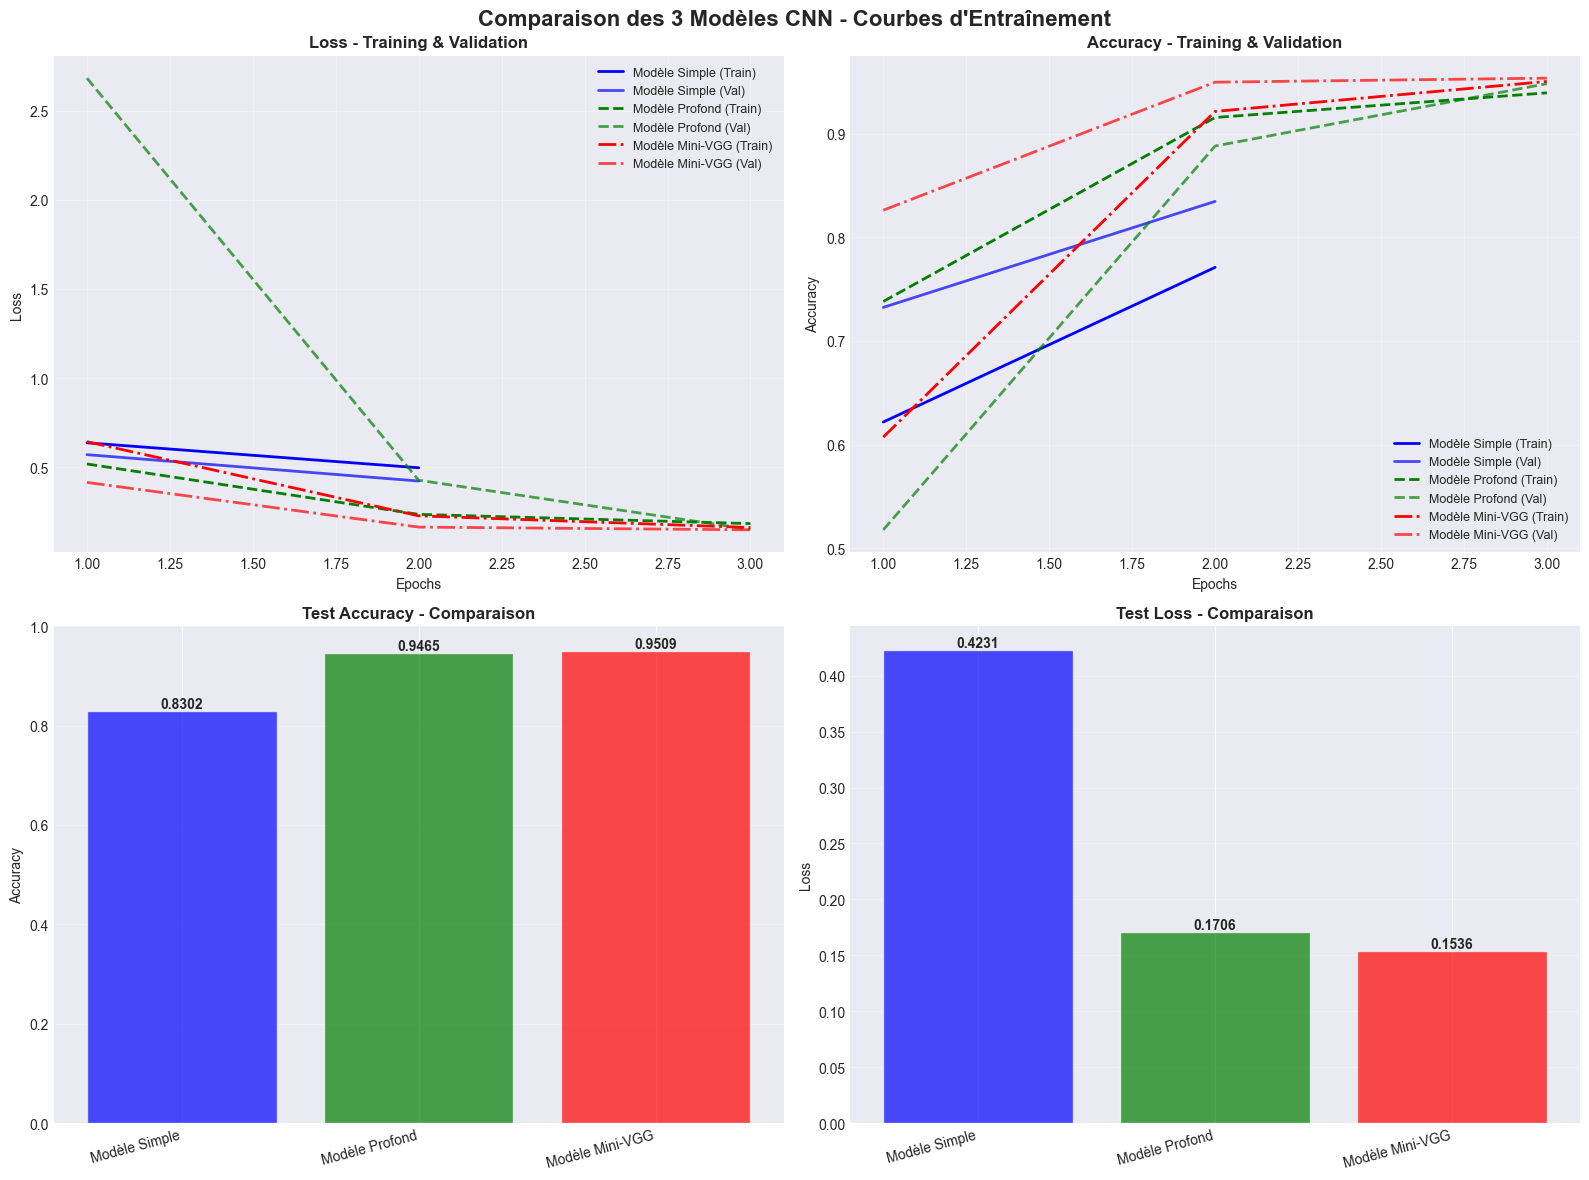


 Graphiques générés avec succès!


In [31]:

# ========== 1. MÉTRIQUES D'ÉVALUATION DÉTAILLÉES ==========
print("=" * 70)
print("MÉTRIQUES D'ÉVALUATION DÉTAILLÉES")
print("=" * 70)

# Évaluation complète sur le set de test
evaluation_results = {}

for name, mdl, hist in [
    ('Modèle Simple', model_simple, hist_simple_tf),
    ('Modèle Profond', model_deep, hist_deep_tf),
    ('Modèle Mini-VGG', model_vgg, hist_vgg_tf)
]:
    print(f"\n--- {name} ---")
    try:
        # Évaluation sur test set
        test_loss, test_acc = mdl.evaluate(test_ds_eval, verbose=0)
        evaluation_results[name] = {
            'test_loss': test_loss,
            'test_acc': test_acc,
            'history': hist.history if hasattr(hist, 'history') else None
        }
        
        # Métriques finales d'entraînement
        if hist.history:
            final_train_loss = hist.history['loss'][-1]
            final_train_acc = hist.history['accuracy'][-1]
            final_val_loss = hist.history['val_loss'][-1]
            final_val_acc = hist.history['val_accuracy'][-1]
            
            print(f"  Train - Loss: {final_train_loss:.4f} | Accuracy: {final_train_acc:.4f}")
            print(f"  Val   - Loss: {final_val_loss:.4f} | Accuracy: {final_val_acc:.4f}")
            print(f"  Test  - Loss: {test_loss:.4f} | Accuracy: {test_acc:.4f}")
        
    except Exception as e:
        print(f"  ERREUR lors de l'évaluation: {str(e)[:80]}")

# ========== 2. TABLEAU RÉCAPITULATIF ==========
print("\n" + "=" * 70)
print("TABLEAU RÉCAPITULATIF DES PERFORMANCES")
print("=" * 70)

results_df = []
for name, results in evaluation_results.items():
    if results['history']:
        results_df.append({
            'Modèle': name,
            'Train Acc': f"{results['history']['accuracy'][-1]:.4f}",
            'Val Acc': f"{results['history']['val_accuracy'][-1]:.4f}",
            'Test Acc': f"{results['test_acc']:.4f}",
            'Train Loss': f"{results['history']['loss'][-1]:.4f}",
            'Val Loss': f"{results['history']['val_loss'][-1]:.4f}",
            'Test Loss': f"{results['test_loss']:.4f}"
        })

if results_df:
    summary_df = pd.DataFrame(results_df)
    print("\n" + summary_df.to_string(index=False))

# ========== 3. VISUALISATION DES COURBES D'ENTRAÎNEMENT ==========
print("\n" + "=" * 70)
print("GÉNÉRATION DES COURBES D'ENTRAÎNEMENT")
print("=" * 70)

# Configuration des graphiques
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comparaison des 3 Modèles CNN - Courbes d\'Entraînement', fontsize=16, fontweight='bold')

colors = {'Modèle Simple': 'blue', 'Modèle Profond': 'green', 'Modèle Mini-VGG': 'red'}
linestyles = {'Modèle Simple': '-', 'Modèle Profond': '--', 'Modèle Mini-VGG': '-.'}

# 1. Training & Validation Loss
ax1 = axes[0, 0]
for name, results in evaluation_results.items():
    if results['history']:
        epochs = range(1, len(results['history']['loss']) + 1)
        ax1.plot(epochs, results['history']['loss'], 
                label=f'{name} (Train)', 
                color=colors.get(name, 'black'),
                linestyle=linestyles.get(name, '-'),
                linewidth=2)
        ax1.plot(epochs, results['history']['val_loss'], 
                label=f'{name} (Val)', 
                color=colors.get(name, 'black'),
                linestyle=linestyles.get(name, '--'),
                linewidth=2, alpha=0.7)
ax1.set_title('Loss - Training & Validation', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)

# 2. Training & Validation Accuracy
ax2 = axes[0, 1]
for name, results in evaluation_results.items():
    if results['history']:
        epochs = range(1, len(results['history']['accuracy']) + 1)
        ax2.plot(epochs, results['history']['accuracy'], 
                label=f'{name} (Train)', 
                color=colors.get(name, 'black'),
                linestyle=linestyles.get(name, '-'),
                linewidth=2)
        ax2.plot(epochs, results['history']['val_accuracy'], 
                label=f'{name} (Val)', 
                color=colors.get(name, 'black'),
                linestyle=linestyles.get(name, '--'),
                linewidth=2, alpha=0.7)
ax2.set_title('Accuracy - Training & Validation', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend(loc='best', fontsize=9)
ax2.grid(True, alpha=0.3)

# 3. Comparaison Test Accuracy
ax3 = axes[1, 0]
model_names = list(evaluation_results.keys())
test_accs = [evaluation_results[name]['test_acc'] for name in model_names]
bars = ax3.bar(model_names, test_accs, color=[colors.get(name, 'gray') for name in model_names], alpha=0.7)
ax3.set_title('Test Accuracy - Comparaison', fontsize=12, fontweight='bold')
ax3.set_ylabel('Accuracy')
ax3.set_ylim([0, 1])
ax3.grid(True, alpha=0.3, axis='y')
# Ajouter les valeurs sur les barres
for bar, acc in zip(bars, test_accs):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.4f}',
             ha='center', va='bottom', fontweight='bold')
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=15, ha='right')

# 4. Comparaison Test Loss
ax4 = axes[1, 1]
test_losses = [evaluation_results[name]['test_loss'] for name in model_names]
bars = ax4.bar(model_names, test_losses, color=[colors.get(name, 'gray') for name in model_names], alpha=0.7)
ax4.set_title('Test Loss - Comparaison', fontsize=12, fontweight='bold')
ax4.set_ylabel('Loss')
ax4.grid(True, alpha=0.3, axis='y')
# Ajouter les valeurs sur les barres
for bar, loss in zip(bars, test_losses):
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
             f'{loss:.4f}',
             ha='center', va='bottom', fontweight='bold')
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=15, ha='right')

plt.tight_layout()
plt.show()

print("\n Graphiques générés avec succès!")


## 9. Étude comparative des modèles - Analyse détaillée basée sur l'Accuracy

Cette section présente une analyse comparative approfondie des 3 modèles CNN implémentés, avec un focus sur les métriques d'accuracy (train, validation, test) ainsi que d'autres métriques pertinentes pour identifier le meilleur modèle.


ÉTUDE COMPARATIVE DES MODÈLES - ANALYSE BASÉE SUR L'ACCURACY

Analyse de Modèle Simple


2025-11-03 15:39:04.929539: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2025-11-03 15:39:13.422194: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  Train Accuracy:   0.7711 (77.11%)
  Val Accuracy:     0.8348 (83.48%)
  Test Accuracy:    0.8302 (83.02%)
  Train Loss:       0.4973
  Val Loss:         0.4229
  Test Loss:        0.4231
  Precision:        0.8523
  Recall:           0.7987
  F1-Score:         0.8247
    Train-Val Gap:    -0.0637 (-6.37%)
   Val-Test Gap:      0.0046 (+0.46%)

Analyse de Modèle Profond


2025-11-03 15:39:19.978480: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2025-11-03 15:39:31.314371: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  Train Accuracy:   0.9396 (93.96%)
  Val Accuracy:     0.9485 (94.85%)
  Test Accuracy:    0.9465 (94.65%)
  Train Loss:       0.1842
  Val Loss:         0.1517
  Test Loss:        0.1706
  Precision:        0.9787
  Recall:           0.9129
  F1-Score:         0.9447
    Train-Val Gap:    -0.0089 (-0.89%)
   Val-Test Gap:      0.0019 (+0.19%)

Analyse de Modèle Mini-VGG


2025-11-03 15:39:44.181141: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
2025-11-03 15:40:02.540235: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


  Train Accuracy:   0.9506 (95.06%)
  Val Accuracy:     0.9538 (95.38%)
  Test Accuracy:    0.9509 (95.09%)
  Train Loss:       0.1621
  Val Loss:         0.1495
  Test Loss:        0.1536
  Precision:        0.9717
  Recall:           0.9289
  F1-Score:         0.9498
    Train-Val Gap:    -0.0031 (-0.31%)
   Val-Test Gap:      0.0029 (+0.29%)

TABLEAU COMPARATIF DES PERFORMANCES

         Modèle  Train Accuracy  Val Accuracy  Test Accuracy  Train Loss  Val Loss  Test Loss  Precision   Recall  F1-Score  Train-Val Gap  Val-Test Gap  Best Accuracy
Modèle Mini-VGG        0.950648      0.953798       0.950895    0.162107  0.149491   0.153630   0.971660 0.928882  0.949790      -0.003150      0.002903       0.953798
 Modèle Profond        0.939606      0.948476       0.946541    0.184210  0.151736   0.170611   0.978734 0.912917  0.944681      -0.008870      0.001935       0.948476
  Modèle Simple        0.771073      0.834785       0.830189    0.497270  0.422890   0.423078   0.852349 0.7987

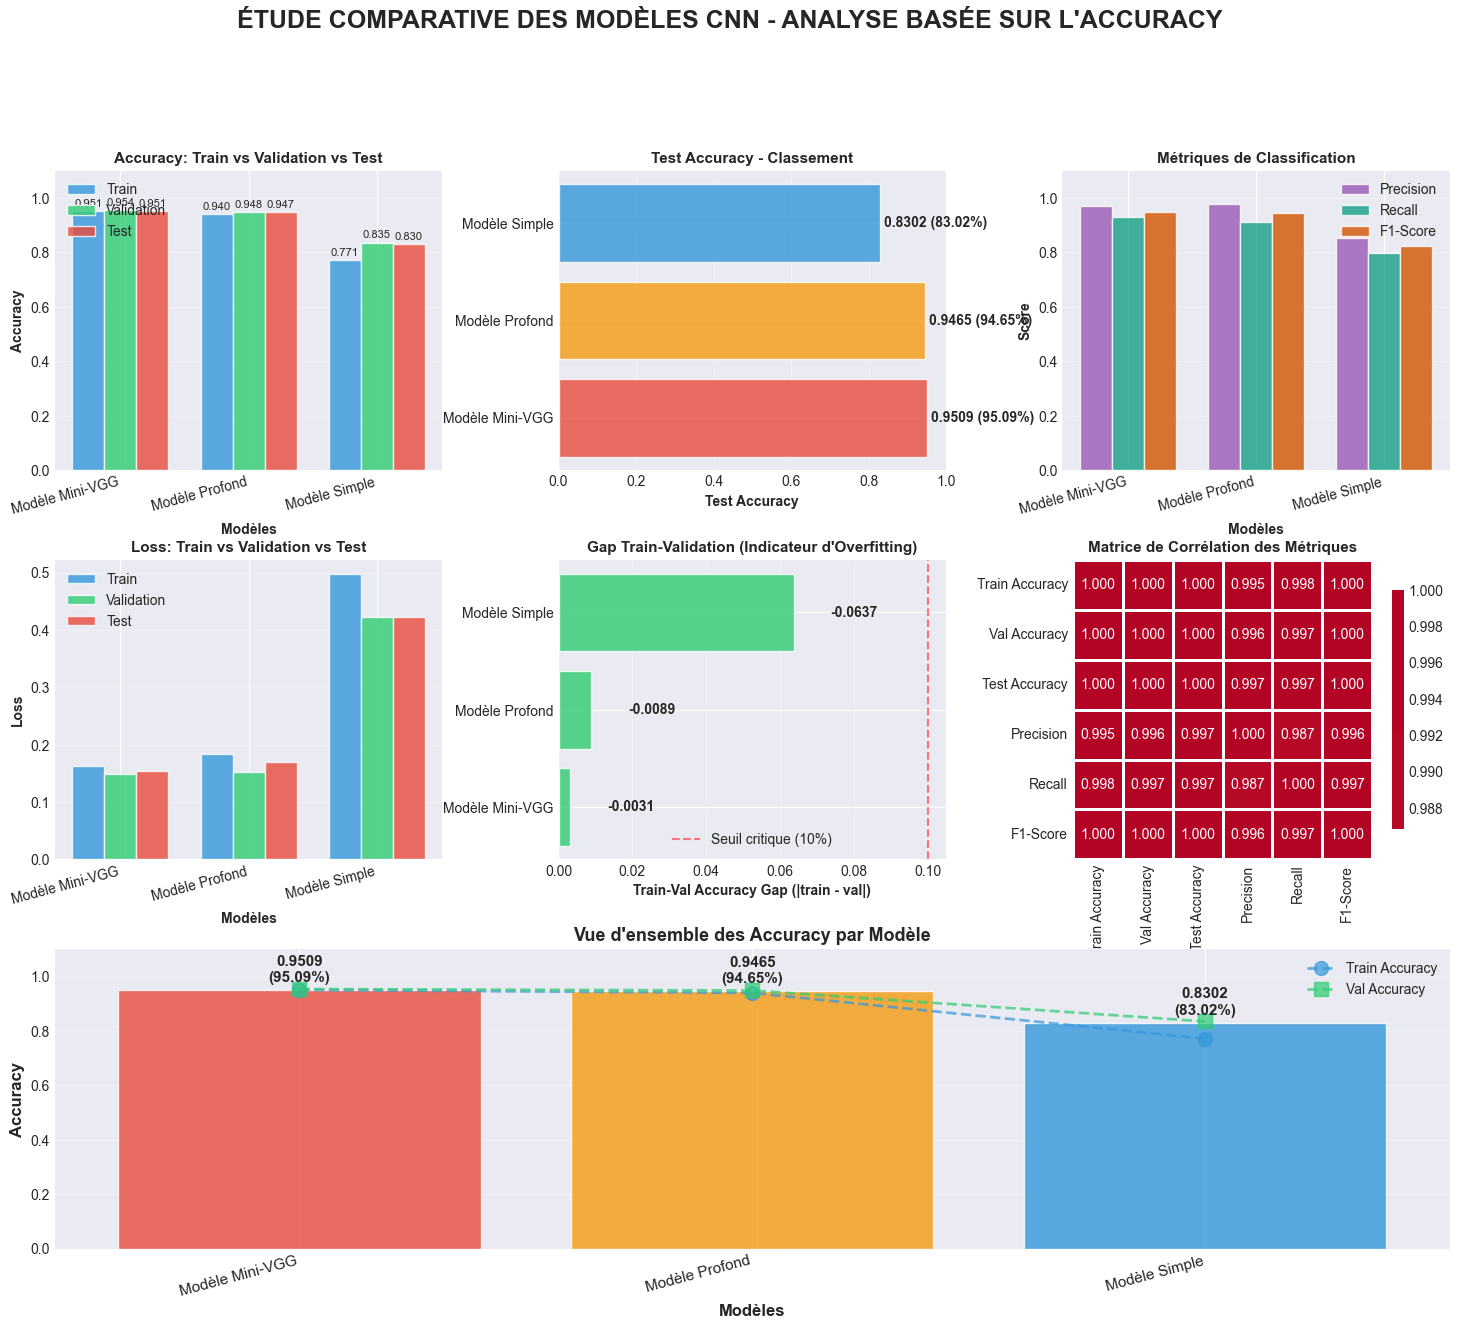


 STATISTIQUES COMPARATIVES

Test Accuracy:
  Moyenne: 0.9092 (90.92%)
  Écart-type: 0.0685
  Min: 0.8302 (83.02%)
  Max: 0.9509 (95.09%)
  Écart (Max-Min): 0.1207

F1-Score:
  Moyenne: 0.9064
  Max: 0.9498

Stabilité (Train-Val Gap):
  Moyenne: 0.0252 (2.52%)
  Min (meilleur): 0.0031 (0.31%)
  Max: 0.0637 (6.37%)

Analyse comparative terminée!


In [32]:
# ========== 1. CALCUL DES MÉTRIQUES DÉTAILLÉES ==========
print("=" * 80)
print("ÉTUDE COMPARATIVE DES MODÈLES - ANALYSE BASÉE SUR L'ACCURACY")
print("=" * 80)

# Récupération des métriques d'entraînement et évaluation sur test
comparison_data = []

models_info = [
    ('Modèle Simple', model_simple, hist_simple_tf),
    ('Modèle Profond', model_deep, hist_deep_tf),
    ('Modèle Mini-VGG', model_vgg, hist_vgg_tf)
]

# Prédictions et évaluation détaillée
for name, mdl, hist in models_info:
    print(f"\n{'='*60}")
    print(f"Analyse de {name}")
    print(f"{'='*60}")
    
    try:
        # Métriques d'entraînement finales
        if hist.history:
            train_acc = hist.history['accuracy'][-1]
            val_acc = hist.history['val_accuracy'][-1]
            train_loss = hist.history['loss'][-1]
            val_loss = hist.history['val_loss'][-1]
            
            # Évaluation sur test
            test_loss, test_acc = mdl.evaluate(test_ds_eval, verbose=0)
            
            # Prédictions pour calcul de métriques supplémentaires
            y_true_list = []
            y_pred_list = []
            
            for batch_images, batch_labels in test_ds_eval.take(100):  # Limite pour éviter timeout
                y_true_list.extend(batch_labels.numpy())
                predictions = mdl.predict(batch_images, verbose=0)
                y_pred_list.extend((predictions > 0.5).astype(int).flatten())
            
            if len(y_true_list) > 0 and len(y_pred_list) > 0:
                y_true = np.array(y_true_list)
                y_pred = np.array(y_pred_list)
                
                # Métriques détaillées
                precision = precision_score(y_true, y_pred, zero_division=0)
                recall = recall_score(y_true, y_pred, zero_division=0)
                f1 = f1_score(y_true, y_pred, zero_division=0)
                
                # Calcul du gap train-val (indicateur d'overfitting)
                train_val_gap = train_acc - val_acc
                val_test_gap = val_acc - test_acc
                
                comparison_data.append({
                    'Modèle': name,
                    'Train Accuracy': train_acc,
                    'Val Accuracy': val_acc,
                    'Test Accuracy': test_acc,
                    'Train Loss': train_loss,
                    'Val Loss': val_loss,
                    'Test Loss': test_loss,
                    'Precision': precision,
                    'Recall': recall,
                    'F1-Score': f1,
                    'Train-Val Gap': train_val_gap,
                    'Val-Test Gap': val_test_gap,
                    'Best Accuracy': max(train_acc, val_acc, test_acc)
                })
                
                print(f"  Train Accuracy:   {train_acc:.4f} ({train_acc*100:.2f}%)")
                print(f"  Val Accuracy:     {val_acc:.4f} ({val_acc*100:.2f}%)")
                print(f"  Test Accuracy:    {test_acc:.4f} ({test_acc*100:.2f}%)")
                print(f"  Train Loss:       {train_loss:.4f}")
                print(f"  Val Loss:         {val_loss:.4f}")
                print(f"  Test Loss:        {test_loss:.4f}")
                print(f"  Precision:        {precision:.4f}")
                print(f"  Recall:           {recall:.4f}")
                print(f"  F1-Score:         {f1:.4f}")
                print(f"    Train-Val Gap:    {train_val_gap:.4f} ({'+' if train_val_gap > 0 else ''}{train_val_gap*100:.2f}%)")
                print(f"   Val-Test Gap:      {val_test_gap:.4f} ({'+' if val_test_gap > 0 else ''}{val_test_gap*100:.2f}%)")
                
        else:
            print(f"    Historique d'entraînement non disponible")
            
    except Exception as e:
        print(f"   Erreur lors de l'analyse: {str(e)[:80]}")

# ========== 2. TABLEAU COMPARATIF COMPLET ==========
print(f"\n{'='*80}")
print("TABLEAU COMPARATIF DES PERFORMANCES")
print(f"{'='*80}")

if comparison_data:
    df_comparison = pd.DataFrame(comparison_data)
    
    # Tri par Test Accuracy (descendant)
    df_comparison = df_comparison.sort_values('Test Accuracy', ascending=False)
    
    print("\n" + df_comparison.to_string(index=False))
    
    # Sauvegarde du DataFrame pour analyse ultérieure
    comparison_df = df_comparison.copy()
    
    # ========== 3. IDENTIFICATION DU MEILLEUR MODÈLE ==========
    print(f"\n{'='*80}")
    print(" IDENTIFICATION DU MEILLEUR MODÈLE")
    print(f"{'='*80}")
    
    best_test_acc = df_comparison.loc[df_comparison['Test Accuracy'].idxmax()]
    best_f1 = df_comparison.loc[df_comparison['F1-Score'].idxmax()]
    most_stable = df_comparison.loc[df_comparison['Train-Val Gap'].abs().idxmin()]
    
    print(f"\n Meilleur Test Accuracy:")
    print(f"   Modèle: {best_test_acc['Modèle']}")
    print(f"   Test Accuracy: {best_test_acc['Test Accuracy']:.4f} ({best_test_acc['Test Accuracy']*100:.2f}%)")
    print(f"   Train Accuracy: {best_test_acc['Train Accuracy']:.4f}")
    print(f"   Val Accuracy: {best_test_acc['Val Accuracy']:.4f}")
    
    print(f"\n Meilleur F1-Score:")
    print(f"   Modèle: {best_f1['Modèle']}")
    print(f"   F1-Score: {best_f1['F1-Score']:.4f}")
    print(f"   Precision: {best_f1['Precision']:.4f}")
    print(f"   Recall: {best_f1['Recall']:.4f}")
    
    print(f"\n Modèle le plus stable (moins d'overfitting):")
    print(f"   Modèle: {most_stable['Modèle']}")
    print(f"   Train-Val Gap: {most_stable['Train-Val Gap']:.4f} ({most_stable['Train-Val Gap']*100:.2f}%)")
    print(f"   Val-Test Gap: {most_stable['Val-Test Gap']:.4f} ({most_stable['Val-Test Gap']*100:.2f}%)")
    
    # ========== 4. VISUALISATIONS COMPARATIVES ==========
    print(f"\n{'='*80}")
    print(" GÉNÉRATION DES VISUALISATIONS COMPARATIVES")
    print(f"{'='*80}")
    
    # Configuration du style
    plt.style.use('seaborn-v0_8-darkgrid')
    sns.set_palette("husl")
    
    # Figure principale avec plusieurs sous-graphiques
    fig = plt.figure(figsize=(18, 14))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    fig.suptitle('ÉTUDE COMPARATIVE DES MODÈLES CNN - ANALYSE BASÉE SUR L\'ACCURACY', 
                 fontsize=18, fontweight='bold', y=0.995)
    
    # 1. Comparaison des Accuracy (Train/Val/Test)
    ax1 = fig.add_subplot(gs[0, 0])
    x = np.arange(len(df_comparison))
    width = 0.25
    ax1.bar(x - width, df_comparison['Train Accuracy'], width, label='Train', alpha=0.8, color='#3498db')
    ax1.bar(x, df_comparison['Val Accuracy'], width, label='Validation', alpha=0.8, color='#2ecc71')
    ax1.bar(x + width, df_comparison['Test Accuracy'], width, label='Test', alpha=0.8, color='#e74c3c')
    ax1.set_xlabel('Modèles', fontweight='bold')
    ax1.set_ylabel('Accuracy', fontweight='bold')
    ax1.set_title('Accuracy: Train vs Validation vs Test', fontweight='bold', fontsize=11)
    ax1.set_xticks(x)
    ax1.set_xticklabels(df_comparison['Modèle'], rotation=15, ha='right')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.set_ylim([0, 1.1])
    # Ajouter les valeurs
    for i, (train, val, test) in enumerate(zip(df_comparison['Train Accuracy'], 
                                                df_comparison['Val Accuracy'], 
                                                df_comparison['Test Accuracy'])):
        ax1.text(i-width, train + 0.01, f'{train:.3f}', ha='center', va='bottom', fontsize=8)
        ax1.text(i, val + 0.01, f'{val:.3f}', ha='center', va='bottom', fontsize=8)
        ax1.text(i+width, test + 0.01, f'{test:.3f}', ha='center', va='bottom', fontsize=8)
    
    # 2. Test Accuracy uniquement (barres horizontales)
    ax2 = fig.add_subplot(gs[0, 1])
    bars = ax2.barh(df_comparison['Modèle'], df_comparison['Test Accuracy'], 
                    color=['#e74c3c', '#f39c12', '#3498db'][:len(df_comparison)], alpha=0.8)
    ax2.set_xlabel('Test Accuracy', fontweight='bold')
    ax2.set_title('Test Accuracy - Classement', fontweight='bold', fontsize=11)
    ax2.set_xlim([0, 1])
    ax2.grid(True, alpha=0.3, axis='x')
    # Ajouter les valeurs
    for i, (bar, acc) in enumerate(zip(bars, df_comparison['Test Accuracy'])):
        ax2.text(acc + 0.01, i, f'{acc:.4f} ({acc*100:.2f}%)', 
                va='center', fontweight='bold', fontsize=10)
    
    # 3. Métriques de classification (Precision, Recall, F1)
    ax3 = fig.add_subplot(gs[0, 2])
    x = np.arange(len(df_comparison))
    width = 0.25
    ax3.bar(x - width, df_comparison['Precision'], width, label='Precision', alpha=0.8, color='#9b59b6')
    ax3.bar(x, df_comparison['Recall'], width, label='Recall', alpha=0.8, color='#16a085')
    ax3.bar(x + width, df_comparison['F1-Score'], width, label='F1-Score', alpha=0.8, color='#d35400')
    ax3.set_xlabel('Modèles', fontweight='bold')
    ax3.set_ylabel('Score', fontweight='bold')
    ax3.set_title('Métriques de Classification', fontweight='bold', fontsize=11)
    ax3.set_xticks(x)
    ax3.set_xticklabels(df_comparison['Modèle'], rotation=15, ha='right')
    ax3.legend()
    ax3.grid(True, alpha=0.3, axis='y')
    ax3.set_ylim([0, 1.1])
    
    # 4. Comparaison des Loss
    ax4 = fig.add_subplot(gs[1, 0])
    x = np.arange(len(df_comparison))
    width = 0.25
    ax4.bar(x - width, df_comparison['Train Loss'], width, label='Train', alpha=0.8, color='#3498db')
    ax4.bar(x, df_comparison['Val Loss'], width, label='Validation', alpha=0.8, color='#2ecc71')
    ax4.bar(x + width, df_comparison['Test Loss'], width, label='Test', alpha=0.8, color='#e74c3c')
    ax4.set_xlabel('Modèles', fontweight='bold')
    ax4.set_ylabel('Loss', fontweight='bold')
    ax4.set_title('Loss: Train vs Validation vs Test', fontweight='bold', fontsize=11)
    ax4.set_xticks(x)
    ax4.set_xticklabels(df_comparison['Modèle'], rotation=15, ha='right')
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='y')
    
    # 5. Gaps d'overfitting (Train-Val Gap)
    ax5 = fig.add_subplot(gs[1, 1])
    bars = ax5.barh(df_comparison['Modèle'], df_comparison['Train-Val Gap'].abs(), 
                    color=['#e74c3c' if x > 0.1 else '#2ecc71' for x in df_comparison['Train-Val Gap'].abs()], 
                    alpha=0.8)
    ax5.set_xlabel('Train-Val Accuracy Gap (|train - val|)', fontweight='bold')
    ax5.set_title('Gap Train-Validation (Indicateur d\'Overfitting)', fontweight='bold', fontsize=11)
    ax5.axvline(x=0.1, color='red', linestyle='--', alpha=0.5, label='Seuil critique (10%)')
    ax5.legend()
    ax5.grid(True, alpha=0.3, axis='x')
    # Ajouter les valeurs
    for i, (bar, gap) in enumerate(zip(bars, df_comparison['Train-Val Gap'])):
        ax5.text(bar.get_width() + 0.01, i, f'{gap:+.4f}', va='center', fontweight='bold', fontsize=10)
    
    # 6. Matrice de corrélation des métriques
    ax6 = fig.add_subplot(gs[1, 2])
    metrics_corr = df_comparison[['Train Accuracy', 'Val Accuracy', 'Test Accuracy', 
                                   'Precision', 'Recall', 'F1-Score']].corr()
    sns.heatmap(metrics_corr, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
                square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax6)
    ax6.set_title('Matrice de Corrélation des Métriques', fontweight='bold', fontsize=11)
    
    # 7. Comparaison Test Accuracy avec intervalles
    ax7 = fig.add_subplot(gs[2, :])
    x_pos = np.arange(len(df_comparison))
    bars = ax7.bar(x_pos, df_comparison['Test Accuracy'], 
                    color=['#e74c3c', '#f39c12', '#3498db'][:len(df_comparison)], alpha=0.8)
    
    # Ajouter des lignes pour Train et Val Accuracy
    ax7.plot(x_pos, df_comparison['Train Accuracy'], 'o--', color='#3498db', 
             linewidth=2, markersize=10, label='Train Accuracy', alpha=0.7)
    ax7.plot(x_pos, df_comparison['Val Accuracy'], 's--', color='#2ecc71', 
             linewidth=2, markersize=10, label='Val Accuracy', alpha=0.7)
    
    ax7.set_xlabel('Modèles', fontweight='bold', fontsize=12)
    ax7.set_ylabel('Accuracy', fontweight='bold', fontsize=12)
    ax7.set_title('Vue d\'ensemble des Accuracy par Modèle', fontweight='bold', fontsize=13)
    ax7.set_xticks(x_pos)
    ax7.set_xticklabels(df_comparison['Modèle'], rotation=15, ha='right', fontsize=11)
    ax7.legend(fontsize=10)
    ax7.grid(True, alpha=0.3, axis='y')
    ax7.set_ylim([0, 1.1])
    
    # Ajouter les valeurs sur les barres Test
    for i, (bar, acc) in enumerate(zip(bars, df_comparison['Test Accuracy'])):
        height = bar.get_height()
        ax7.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{acc:.4f}\n({acc*100:.2f}%)', ha='center', va='bottom', 
                fontweight='bold', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    # ========== 5. RÉSUMÉ STATISTIQUE ==========
    print(f"\n{'='*80}")
    print(" STATISTIQUES COMPARATIVES")
    print(f"{'='*80}")
    
    print(f"\nTest Accuracy:")
    print(f"  Moyenne: {df_comparison['Test Accuracy'].mean():.4f} ({df_comparison['Test Accuracy'].mean()*100:.2f}%)")
    print(f"  Écart-type: {df_comparison['Test Accuracy'].std():.4f}")
    print(f"  Min: {df_comparison['Test Accuracy'].min():.4f} ({df_comparison['Test Accuracy'].min()*100:.2f}%)")
    print(f"  Max: {df_comparison['Test Accuracy'].max():.4f} ({df_comparison['Test Accuracy'].max()*100:.2f}%)")
    print(f"  Écart (Max-Min): {(df_comparison['Test Accuracy'].max() - df_comparison['Test Accuracy'].min()):.4f}")
    
    print(f"\nF1-Score:")
    print(f"  Moyenne: {df_comparison['F1-Score'].mean():.4f}")
    print(f"  Max: {df_comparison['F1-Score'].max():.4f}")
    
    print(f"\nStabilité (Train-Val Gap):")
    print(f"  Moyenne: {df_comparison['Train-Val Gap'].abs().mean():.4f} ({df_comparison['Train-Val Gap'].abs().mean()*100:.2f}%)")
    print(f"  Min (meilleur): {df_comparison['Train-Val Gap'].abs().min():.4f} ({df_comparison['Train-Val Gap'].abs().min()*100:.2f}%)")
    print(f"  Max: {df_comparison['Train-Val Gap'].abs().max():.4f} ({df_comparison['Train-Val Gap'].abs().max()*100:.2f}%)")
    
    print(f"\n{'='*80}")
    print("Analyse comparative terminée!")
    print(f"{'='*80}")
    
else:
    print(" Aucune donnée disponible pour la comparaison.")



## 10. Sauvegarde du meilleur modèle

Identification et sauvegarde du meilleur modèle basé sur les métriques d'évaluation (Test Accuracy), ainsi que sauvegarde des métriques et informations importantes.


In [34]:
print("=" * 80)
print("SAUVEGARDE DU MEILLEUR MODÈLE")
print("=" * 80)

# Création du dossier de sauvegarde
save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)
print(f"\n Dossier de sauvegarde: {save_dir}/")

# Identification du meilleur modèle basé sur Test Accuracy
models_info = [
    ('Modèle Simple', model_simple, hist_simple_tf, 'simple'),
    ('Modèle Profond', model_deep, hist_deep_tf, 'deep'),
    ('Modèle Mini-VGG', model_vgg, hist_vgg_tf, 'vgg')
]

best_model = None
best_name = None
best_short_name = None
best_test_acc = 0.0
best_metrics = {}
best_history = None

print("\n" + "-" * 80)
print("ÉVALUATION DES MODÈLES POUR IDENTIFICATION DU MEILLEUR")
print("-" * 80)

for name, mdl, hist, short_name in models_info:
    try:
        test_loss, test_acc = mdl.evaluate(test_ds_eval, verbose=0)
        print(f"\n{name}:")
        print(f"  Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
        print(f"  Test Loss: {test_loss:.4f}")
        
        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_model = mdl
            best_name = name
            best_short_name = short_name
            best_history = hist.history if hist.history else None
            
            best_metrics = {
                'model_name': name,
                'short_name': short_name,
                'test_accuracy': float(test_acc),
                'test_loss': float(test_loss),
                'train_accuracy': float(hist.history['accuracy'][-1]) if hist.history else None,
                'val_accuracy': float(hist.history['val_accuracy'][-1]) if hist.history else None,
                'train_loss': float(hist.history['loss'][-1]) if hist.history else None,
                'val_loss': float(hist.history['val_loss'][-1]) if hist.history else None,
                'epochs_trained': len(hist.history['loss']) if hist.history else None,
                'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
            }
            
    except Exception as e:
        print(f"    Erreur: {str(e)[:60]}")

# Sauvegarde du meilleur modèle
if best_model is not None:
    print("\n" + "=" * 80)
    print(f" MEILLEUR MODÈLE: {best_name}")
    print(f"   Test Accuracy: {best_test_acc:.4f} ({best_test_acc*100:.2f}%)")
    print("=" * 80)
    
    # 1. Sauvegarde format .keras
    model_path = os.path.join(save_dir, f"best_model_{best_short_name}.keras")
    best_model.save(model_path)
    print(f"\n Modèle sauvegardé: {model_path}")
    
    # 2. Sauvegarde format SavedModel (utiliser export() pour SavedModel)
    model_saved_path = os.path.join(save_dir, f"best_model_{best_short_name}")
    best_model.export(model_saved_path)
    print(f" Modèle sauvegardé (SavedModel): {model_saved_path}/")
    
    # 3. Sauvegarde métriques JSON
    metrics_path = os.path.join(save_dir, "best_model_metrics.json")
    with open(metrics_path, 'w', encoding='utf-8') as f:
        json.dump(best_metrics, f, indent=4, ensure_ascii=False)
    print(f" Métriques sauvegardées: {metrics_path}")
    
    # 4. Sauvegarde historique
    if best_history:
        history_path = os.path.join(save_dir, f"best_model_{best_short_name}_history.json")
        history_dict = {k: [float(v) for v in values] for k, values in best_history.items()}
        with open(history_path, 'w', encoding='utf-8') as f:
            json.dump(history_dict, f, indent=4)
        print(f" Historique sauvegardé: {history_path}")
    
    # 5. Résumé texte
    summary_path = os.path.join(save_dir, "model_summary.txt")
    with open(summary_path, 'w', encoding='utf-8') as f:
        f.write("=" * 80 + "\n")
        f.write("RÉSUMÉ DU MEILLEUR MODÈLE\n")
        f.write("=" * 80 + "\n\n")
        f.write(f"Modèle: {best_name}\n")
        f.write(f"Date: {best_metrics['timestamp']}\n\n")
        f.write("MÉTRIQUES:\n")
        f.write("-" * 80 + "\n")
        f.write(f"Test Accuracy:  {best_metrics['test_accuracy']:.4f} ({best_metrics['test_accuracy']*100:.2f}%)\n")
        f.write(f"Test Loss:      {best_metrics['test_loss']:.4f}\n")
        if best_metrics['train_accuracy']:
            f.write(f"Train Accuracy: {best_metrics['train_accuracy']:.4f}\n")
        if best_metrics['val_accuracy']:
            f.write(f"Val Accuracy:   {best_metrics['val_accuracy']:.4f}\n")
        f.write("\nARCHITECTURE:\n")
        f.write("-" * 80 + "\n")
        best_model.summary(print_fn=lambda x: f.write(x + "\n"))
    
    print(f" Résumé sauvegardé: {summary_path}")
    
    print("\n" + "=" * 80)
    print("ARCHITECTURE DU MODÈLE")
    print("=" * 80)
    best_model.summary()
    
    print("\n Pour charger le modèle:")
    print(f"  loaded_model = tf.keras.models.load_model('{model_path}')")
    print(f"\n Fichiers sauvegardés dans: {save_dir}/")
    print("\n SAUVEGARDE TERMINÉE!")
    
else:
    print("\n  Erreur: aucun modèle sauvegardé")


SAUVEGARDE DU MEILLEUR MODÈLE

 Dossier de sauvegarde: saved_models/

--------------------------------------------------------------------------------
ÉVALUATION DES MODÈLES POUR IDENTIFICATION DU MEILLEUR
--------------------------------------------------------------------------------


2025-11-03 15:46:49.641593: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]



Modèle Simple:
  Test Accuracy: 0.8302 (83.02%)
  Test Loss: 0.4231


2025-11-03 15:46:56.384521: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]



Modèle Profond:
  Test Accuracy: 0.9465 (94.65%)
  Test Loss: 0.1706


...

 Total params: 15,018,341 (57.29 MB)

 Trainable params: 5,006,113 (19.10 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,012,228 (38.19 MB)


 Pour charger le modèle:
  loaded_model = tf.keras.models.load_model('saved_models/best_model_vgg.keras')

 Fichiers sauvegardés dans: saved_models/

 SAUVEGARDE TERMINÉE!


## 11. Déploiement du meilleur modèle dans un serveur Flask

Création d'une application Flask pour déployer le modèle et permettre la prédiction via une interface web.


In [ ]:
# Instructions pour déployer le serveur Flask
print("=" * 80)
print("DÉPLOIEMENT DU SERVEUR FLASK")
print("=" * 80)

print("\n ÉTAPES POUR DÉPLOYER LE SERVEUR:")
print("-" * 80)
print("\n1. Installer les dépendances:")
print("   pip install -r requirements.txt")
print("\n2. Vérifier que le modèle est sauvegardé:")
print("   - Le modèle doit être dans le dossier 'saved_models/'")
print("   - Format: .keras ou SavedModel")
print("\n3. Lancer le serveur Flask:")
print("   python app.py")
print("\n4. Accéder à l'application:")
print("   http://127.0.0.1:5000")
print("\n5. Endpoints disponibles:")
print("   - GET  /              : Interface web")
print("   - POST /predict       : Prédiction via formulaire")
print("   - POST /predict_api   : API REST pour prédiction")
print("   - GET  /health        : Vérification de santé du serveur")
print("\n" + "=" * 80)
print(" Le serveur Flask est prêt à être déployé!")
print("=" * 80)


In [ ]:
# OPTIONNEL: Test de l'API Flask (nécessite que le serveur soit lancé)
# Pour tester, lancer d'abord: python app.py
# Puis exécuter cette cellule

import requests
import os

def test_flask_api():
    """Test des endpoints de l'API Flask"""
    base_url = "http://127.0.0.1:5000"
    
    print("=" * 80)
    print("TEST DE L'API FLASK")
    print("=" * 80)
    
    # 1. Health check
    print("\n1. Health Check:")
    try:
        response = requests.get(f"{base_url}/health", timeout=5)
        if response.status_code == 200:
            print(f"    Serveur opérationnel")
            print(f"    {response.json()}")
        else:
            print(f"    Erreur: {response.status_code}")
    except requests.exceptions.ConnectionError:
        print("    Serveur non accessible. Assurez-vous que le serveur Flask est lancé.")
        print("    Lancer: python app.py")
        return
    except Exception as e:
        print(f"    Erreur: {e}")
        return
    
    # 2. Test avec une image (si disponible)
    print("\n2. Test de prédiction:")
    # Chercher une image de test dans le dataset
    test_image_path = None
    if os.path.exists('cell_images'):
        # Chercher une image dans Parasitized ou Uninfected
        for folder in ['Parasitized', 'Uninfected']:
            folder_path = os.path.join('cell_images', folder)
            if os.path.exists(folder_path):
                images = [f for f in os.listdir(folder_path) if f.endswith('.png')]
                if images:
                    test_image_path = os.path.join(folder_path, images[0])
                    break
    
    if test_image_path and os.path.exists(test_image_path):
        try:
            with open(test_image_path, 'rb') as f:
                files = {'file': f}
                response = requests.post(f"{base_url}/predict", files=files, timeout=30)
            
            if response.status_code == 200:
                result = response.json()
                print(f"    Prédiction réussie")
                print(f"    Résultat: {result}")
            else:
                print(f"    Erreur: {response.status_code}")
                print(f"    {response.text}")
        except Exception as e:
            print(f"    Erreur lors de la prédiction: {e}")
    else:
        print("     Aucune image de test trouvée dans cell_images/")
        print("     Vous pouvez tester manuellement via l'interface web")
    
    print("\n" + "=" * 80)
    print(" Pour utiliser l'API, lancez: python app.py")
    print("   Puis accédez à: http://127.0.0.1:5000")
    print("=" * 80)

# Décommenter la ligne suivante pour tester l'API
# test_flask_api()
print(" Pour tester l'API Flask, décommentez la ligne 'test_flask_api()' ci-dessus")
print("   et assurez-vous que le serveur Flask est lancé (python app.py)")
